# F1 race car, part 3: fitting a 5-D aero map from sparse CFD samples

An F1 team's competitive edge runs through its aero map — the multi-dimensional surface
$\bigl(C_L A_{\text{ref}},\,C_D A_{\text{ref}},\,x_{\text{CoP}}\bigr)$ as a function of ride-height,
attitude, and steer — and that map is built one CFD or wind-tunnel sample at a time.
Under the 2022+ FIA Aerodynamic Testing Restriction (ATR, Appendix 6 of the International
Sporting Code), the CFD-hours and wind-tunnel-runs each team gets are *capped on a sliding
scale tied to championship position*: the leader gets the smallest budget, the back of the
grid gets the most. Every sample costs real money and real schedule, and a championship-grade
aero map has to fit smoothly through hundreds, not millions, of probes. In this notebook we
fit a noisy 5-D aero map — $(h_F, h_R, \phi, \beta, \delta)$ → $(C_L, C_D, x_{\text{CoP}})$ —
from a Latin-hypercube of 64 synthetic CFD probes, drop the fitted surrogate into the
Part-1 lap-time simulator, and verify that `jax.grad(lap_time)` through the fitted map
matches the gradient through the analytic truth to within the CFD noise envelope. Reading
time: ~25 min. Runtime: ~4 min on a laptop CPU (default publication mode).

> **Where this sits in the six-part arc.** Part 1 ([`f1_part_1_lap_time_simulator.ipynb`](./f1_part_1_lap_time_simulator.ipynb))
> built the LTS. **Part 2** ([`f1_part_2_setup_optimization.ipynb`](./f1_part_2_setup_optimization.ipynb))
> took `jax.grad(lap_time)` through it — the headline differentiability beat. **Part 3
> (this notebook)** kicks off Series B by fitting a noisy 5-D aero map from sparse CFD
> samples; this is the structural prerequisite for Part 4, where Sobol-decomposition over
> the fitted map will tell the race engineer *where* to spend the next slice of CFD
> budget. Parts 5–6 (Series C) couple the LTS to the SU2 adjoint-CFD solver for closed-loop
> shape optimisation.

## Prerequisites

This notebook assumes the Part-1 lap-time simulator and the Part-2 `lap_time(setup)`
wrapper. We re-import a slimmed-down version of the same plant inline below — the
closed-loop diagram is identical to Part 2's, except the chassis's normal-load + drag
computation now consumes coefficients pulled out of a `LookupTableND` rather than the
flat constants Parts 1+2 used. We also rely on the differentiable-lookup-table workflow
from [`engine_map_fitting_to_mpc.ipynb`](./engine_map_fitting_to_mpc.ipynb): same idea, one
dimension higher.

Familiarity with **Latin-hypercube sampling** (`scipy.stats.qmc.LatinHypercube`) and the
**multilinear-interpolation** kernel is helpful but not required — both get a paragraph of
motivation in their respective sections.

> **Out of scope, on purpose.** Wind-tunnel-vs-CFD scale-factor calibration (the
> $\gamma = C_{L,\text{CFD}} / C_{L,\text{WT}} \approx 1.05$ discrepancy every team
> tracks); RANS-vs-LES turbulence-model selection; mesh-convergence studies; the active
> / passive Reynolds-number dependency that real F1 teams correct for; the
> Sobol-decomposition / budget-allocation question (deferred to Part 4, the wedge this
> notebook sets up); the actual CFD solve (deferred to Part 5 with SU2). For Part 3 the
> scope is: **assume the CFD probes have already been run; what surrogate model
> drops cleanly into our differentiable LTS?**

In [1]:
# Standard scientific Python
from __future__ import annotations

import os
import time as _time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# JAX — float64 throughout so the Pacejka saturation, the bicycle equilibrium, and the
# small-difference checks on the lap-time gradient all resolve cleanly.
from jax import config as _jax_config
_jax_config.update("jax_enable_x64", True)
import jax
import jax.numpy as jnp

# scipy: quasi-Monte-Carlo design + linear least squares only — no scipy.optimize here.
from scipy.stats import qmc

# jaxonomy
import jaxonomy
from jaxonomy import DiagramBuilder, LeafSystem, simulate
from jaxonomy.backend import numpy_api as npa
from jaxonomy.library import Constant, LookupTable1d, LookupTableND
from jaxonomy.library.lookup_table import interp_nd
from jaxonomy.simulation import SimulatorOptions
from jaxonomy.diagnostics import analyze_saturation, analyze_phase_activity
from jaxonomy import logging as jx_logging
jx_logging.set_log_level(jx_logging.ERROR)

# Reproducibility — every random draw lives behind this one constant.
RNG_SEED = 20260517
np.random.seed(RNG_SEED)
KEY = jax.random.PRNGKey(RNG_SEED)
print(f"jaxonomy {jaxonomy.__version__}  |  jax {jax.__version__}")

jaxonomy 2.2.0  |  jax 0.9.2


## 1. Why aero map fitting matters in F1

An F1 car's aerodynamic state is a 5-D point: front and rear ride heights set the underfloor
expansion ratio (the dominant downforce-producing surface since the 2022 ground-effect
regulations); roll angle redistributes loading across the floor edges; sideslip $\beta$
(yaw of the body relative to the velocity vector) introduces an asymmetric pressure field;
and steer $\delta$ alters the front-wing inflow and tyre-wake interaction. The downforce
coefficient $C_L A_{\text{ref}}$, the drag coefficient $C_D A_{\text{ref}}$, and the
centre-of-pressure $x_{\text{CoP}}$ (the longitudinal point at which net aero force acts,
as a fraction of wheelbase from the front axle) all move on this 5-D manifold. The *aero
map* is the team's catalogue of $(C_L, C_D, x_{\text{CoP}})$ at gridded points across that
space; every lap-time prediction, every setup recommendation, every wing-flap angle the
race engineers consider on a Sunday morning is mediated through it.

Building that catalogue is expensive. The 2022 FIA Sporting Regulations (Article 7) and
Appendix 6 of the International Sporting Code cap CFD-teraflop-hours and wind-tunnel-runs
per team on a *sliding scale tied to position in the previous Constructors' Championship*:
the leader gets the smallest budget, the back of the grid gets the most. The published
2026 scale gives the championship leader roughly 70% of the median CFD allowance and
60% of the median wind-tunnel allowance, while the tenth-placed team gets ~115% and
~140% respectively. The asymmetric leverage is obvious — the teams with the most CFD
budget have the least know-how about where to spend it; the teams with the deepest aero
understanding have the smallest budget.

Building a *smooth, differentiable* surrogate from those probes unlocks two things that
every commercial F1 LTS stack (Simulink-based, AVL CRUISE M, IPG CarMaker, Magna's
in-house) leaves on the table today. First, `jax.grad(lap_time)` flows cleanly through
the surrogate — making the Part-2 setup-optimisation gradient computable end-to-end
*through the aero side of the model*, not just the chassis. Second, the surrogate gives
a sample-allocation oracle: given the gradient of lap time w.r.t. each cell of the aero
map, the engineer can rank cells by marginal information value. Today's industry-standard
answer is RBF or kriging surrogates with Tikhonov regularisation built and consumed in
isolation from the lap-time pipeline; *differentiable end-to-end* is the wedge.

## 2. The 5-D design space and the aero outputs

We pin the inputs and outputs precisely before building anything. The five inputs span
the operating envelope of a 2022+-era ground-effect F1 car:

| Symbol | Meaning | Units | Low | Baseline | High |
|---|---|---|---|---|---|
| $h_F$ | Front ride height (sprung height of the front floor edge above the road) | mm | 18 | 25 | 40 |
| $h_R$ | Rear ride height | mm | 30 | 40 | 60 |
| $\phi$ | Roll angle (body roll about the longitudinal axis) | deg | -2.0 | 0.0 | +2.0 |
| $\beta$ | Sideslip / yaw angle of the body relative to the velocity vector | deg | -3.0 | 0.0 | +3.0 |
| $\delta$ | Steer angle at the front axle | deg | -20.0 | 0.0 | +20.0 |

And three outputs:

| Symbol | Meaning | Units | Sign convention |
|---|---|---|---|
| $C_L A_{\text{ref}}$ | Downforce coefficient × reference area | m² | **positive = downforce** (the Part-1 convention) |
| $C_D A_{\text{ref}}$ | Drag coefficient × reference area | m² | positive = retarding force |
| $x_{\text{CoP}}$ | Centre-of-pressure as a fraction of wheelbase from the front axle | - | 0.0 = at front axle; 1.0 = at rear axle |

The intuition behind each input's effect, which we'll encode in the synthetic ground
truth below:

- **Lower $h_F$** increases the underfloor seal, traps more low-pressure region, increases
  $C_L A$. The 2022 ground-effect regulations make this the dominant lever — Mercedes
  spent half of 2022 chasing the porpoising bound on $h_F$.
- **Higher $h_R$** with $h_F$ held increases the *rake angle* $\theta_R \approx
  \arctan((h_R - h_F)/L)$, opens the underfloor diffuser, again increases $C_L A$ but
  *shifts the CoP forward*.
- **Roll $\phi$**: asymmetric pressure across the floor; small symmetric quadratic
  penalty on $C_L A$.
- **Sideslip $\beta$**: large asymmetric effect — $C_L A$ drops quadratically in $\beta$
  (the floor loses its seal), $C_D A$ rises, CoP shifts forward (front-wing keeps
  working in dirty inflow while the floor stalls).
- **Steer $\delta$**: small effect on the bulk car aero but the front-wing camber relative
  to inflow changes — small linear shift in $x_{\text{CoP}}$, small quadratic on $C_D A$.

We hold all coefficient magnitudes in the believable F1 range: $C_L A \approx 3.5\ \text{m}^2$
at nominal trim (which gives roughly $\tfrac{1}{2} \rho C_L A V^2 = 5\,500\ \text{N}$ at
250 km/h, $\sim$0.7 car-weights, consistent with published wind-tunnel data); $C_D A
\approx 1.1\ \text{m}^2$; $x_{\text{CoP}} \approx 0.42$ (typical front-axle bias for a
rear-wing-dominant car).

> **Note on $x_{\text{CoP}}$ vs aero-balance $\beta_{\text{aero,F}}$.** The Part-1 LTS
> parametrises the aero load split as the *fraction carried by the front axle*,
> $\beta_{\text{aero,F}} \in [0.42, 0.48]$. That's mathematically equivalent to the CoP
> fraction we use here — under the bicycle assumption, the moment balance gives
> $\beta_{\text{aero,F}} = 1 - x_{\text{CoP}}$ when $x_{\text{CoP}}$ is measured from
> the front axle. We carry $x_{\text{CoP}}$ as the aero map output because that's what
> a CFD solver reports natively (integrating $\int p\,x\,dA$ over the wetted surface);
> the conversion to $\beta_{\text{aero,F}}$ is one subtraction.

In [2]:
# Inputs: bounds of the 5-D box (in physical units)
AERO_INPUT_NAMES  = ["h_F [mm]", "h_R [mm]", "roll [deg]", "beta [deg]", "delta [deg]"]
AERO_INPUT_LO     = jnp.array([18.0, 30.0, -2.0, -3.0, -20.0])
AERO_INPUT_HI     = jnp.array([40.0, 60.0, +2.0, +3.0, +20.0])
AERO_INPUT_NOMINAL = jnp.array([25.0, 40.0, 0.0, 0.0, 0.0])

# Outputs: order matters — keep it stable across the rest of the notebook
AERO_OUTPUT_NAMES = ["C_L A [m^2]", "C_D A [m^2]", "x_CoP [-]"]


def normalize_inputs(x):
    """Map physical [LO, HI] inputs to [0, 1] (fit-side coordinate)."""
    return (x - AERO_INPUT_LO) / (AERO_INPUT_HI - AERO_INPUT_LO)


def denormalize_inputs(u):
    """Inverse of normalize_inputs (only used to read off physical values for plots)."""
    return AERO_INPUT_LO + u * (AERO_INPUT_HI - AERO_INPUT_LO)


print(f"Input box (physical):")
for n, lo, hi in zip(AERO_INPUT_NAMES, np.asarray(AERO_INPUT_LO), np.asarray(AERO_INPUT_HI)):
    print(f"  {n:14s}: [{lo:+7.1f}, {hi:+7.1f}]")
print(f"Outputs: {AERO_OUTPUT_NAMES}")

Input box (physical):
  h_F [mm]      : [  +18.0,   +40.0]
  h_R [mm]      : [  +30.0,   +60.0]
  roll [deg]    : [   -2.0,    +2.0]
  beta [deg]    : [   -3.0,    +3.0]
  delta [deg]   : [  -20.0,   +20.0]
Outputs: ['C_L A [m^2]', 'C_D A [m^2]', 'x_CoP [-]']


## 3. The ground-truth aero map (synthetic, closed form)

We don't have access to a real F1 team's wind-tunnel data — every team treats theirs as
the deepest of competitive secrets, and the published academic datasets (Toet 2013;
DrivAerML on Hugging Face) cover specific geometries at coarse aero-state coverage. So
we build a believable synthetic truth: closed-form, JAX-traceable, with dependencies on
each input that match the engineering intuition above.

The decomposition is additive in the partial-derivative sense — each input contributes
a term whose magnitude is calibrated against published F1-engineering literature (Toet
2013; Pacifico 2019; Milliken Ch. 16). The signs are physical: lower $h_F$ raises
$C_L A$, more rake shifts CoP forward, sideslip degrades downforce quadratically. The
functional form for each input is the smoothest reasonable function that captures the
qualitative behaviour — a sum of low-order polynomials plus a couple of `tanh`s to keep
the response bounded at the corners of the box.

Concretely:

$$
\begin{aligned}
C_L A(h_F, h_R, \phi, \beta, \delta) \;=\; C_L A^{(0)} \cdot \Big[
  &1 + a_{h_F}^{(L)}(25 - h_F) + a_{h_R}^{(L)}(h_R - 40) + a_{\theta_R}^{(L)} (h_R - h_F) \\
 &- a_{\phi^2}^{(L)} \phi^2 - a_{\beta^2}^{(L)} \beta^2 - a_{\delta^2}^{(L)} \delta^2
\Big]
\end{aligned} \tag{1}
$$

$$
\begin{aligned}
C_D A(h_F, h_R, \phi, \beta, \delta) \;=\; C_D A^{(0)} \cdot \Big[
  &1 + a_{h_F}^{(D)}(25 - h_F) + a_{h_R}^{(D)}(h_R - 40) \\
 &+ a_{\phi^2}^{(D)} \phi^2 + a_{\beta^2}^{(D)} \beta^2 + a_{\delta^2}^{(D)} \delta^2
\Big]
\end{aligned} \tag{2}
$$

$$
x_{\text{CoP}}(h_F, h_R, \phi, \beta, \delta) \;=\; x_{\text{CoP}}^{(0)} +
  c_{\theta_R} (h_R - h_F) + c_\beta \beta + c_\delta \delta \tag{3}
$$

The coefficients (in 1/mm, 1/deg, 1/deg² units as appropriate) are picked from the
direction and order of magnitude in the literature — they're not realistic to the
third significant figure, but the *shape* and the *headline magnitudes* are right.
Dimensional check: $C_L A$ stays in m² because we multiply a unitless bracket by the
baseline coefficient; in the bracket each term is unitless (e.g. `a_h_F^(L) [1/mm] *
(mm)` cancels). Limiting cases: at the nominal point $(h_F, h_R, \phi, \beta, \delta)
= (25, 40, 0, 0, 0)$ the bracket collapses to 1, recovering the Part-1 baseline.

In [3]:
# Baseline aero coefficients — these reproduce the Part-1 LTS at the nominal aero state.
CLA_NOMINAL = 3.5    # m^2
CDA_NOMINAL = 1.1    # m^2
XCOP_NOMINAL = 0.42  # fraction of wheelbase from the front axle


# Coefficients in eqs. (1)-(3). Units annotated; magnitudes calibrated against the
# published F1-engineering literature (see references at the bottom).
# Downforce sensitivities (eq. 1):
A_HF_L     = 0.020        # 1/mm   -- 1mm lower h_F -> +2% C_L A
A_HR_L     = -0.005       # 1/mm   -- raising h_R alone slightly reduces C_L A
A_RAKE_L   = 0.004        # 1/mm   -- per mm of rake (h_R - h_F)
A_PHI2_L   = 0.005        # 1/deg^2 -- roll penalty
A_BETA2_L  = 0.015        # 1/deg^2 -- yaw penalty (sharp)
A_DELTA2_L = 0.00015      # 1/deg^2 -- steer penalty (small)

# Drag sensitivities (eq. 2):
A_HF_D     = -0.004       # 1/mm   -- lower h_F = more drag (sealed floor adds form drag)
A_HR_D     = -0.002       # 1/mm   -- raising h_R reduces drag slightly
A_PHI2_D   = 0.003        # 1/deg^2
A_BETA2_D  = 0.020        # 1/deg^2 -- yaw drag rise is the headline aero penalty
A_DELTA2_D = 0.0002       # 1/deg^2

# CoP sensitivities (eq. 3):
C_RAKE_COP  = -0.001       # per mm of rake (h_R - h_F): more rake -> CoP forward (negative)
C_BETA_COP  = -0.010       # per deg of beta: yaw -> CoP forward
C_DELTA_COP = +0.001       # per deg of steer: small rearward shift on locked-axle steer


@jax.jit
def aero_true(x):
    """Ground-truth aero map.  Input x: shape (5,) in physical units; output: (C_L A, C_D A, x_CoP).

    Args
    ----
    x : jnp.ndarray, shape (5,)
        [h_F (mm), h_R (mm), roll (deg), beta (deg), delta (deg)]

    Returns
    -------
    jnp.ndarray, shape (3,)
        [C_L A (m^2), C_D A (m^2), x_CoP (fraction)]
    """
    h_F, h_R, phi, beta, delta = x[..., 0], x[..., 1], x[..., 2], x[..., 3], x[..., 4]
    rake = h_R - h_F  # positive = rear higher than front

    cla = CLA_NOMINAL * (
        1.0
        + A_HF_L * (25.0 - h_F)
        + A_HR_L * (h_R - 40.0)
        + A_RAKE_L * (rake - (40.0 - 25.0))
        - A_PHI2_L * phi * phi
        - A_BETA2_L * beta * beta
        - A_DELTA2_L * delta * delta
    )
    cda = CDA_NOMINAL * (
        1.0
        + A_HF_D * (25.0 - h_F)
        + A_HR_D * (h_R - 40.0)
        + A_PHI2_D * phi * phi
        + A_BETA2_D * beta * beta
        + A_DELTA2_D * delta * delta
    )
    xcop = (
        XCOP_NOMINAL
        + C_RAKE_COP * (rake - (40.0 - 25.0))
        + C_BETA_COP * beta
        + C_DELTA_COP * delta
    )
    return jnp.stack([cla, cda, xcop], axis=-1)


# Sanity check: at the nominal point we should recover the Part-1 baseline.
_y_nom = aero_true(AERO_INPUT_NOMINAL)
print(f"Aero @ nominal: C_L A = {float(_y_nom[0]):.3f} m^2, "
      f"C_D A = {float(_y_nom[1]):.3f} m^2, x_CoP = {float(_y_nom[2]):.3f}")
print(f"Expected     : C_L A = {CLA_NOMINAL:.3f} m^2, "
      f"C_D A = {CDA_NOMINAL:.3f} m^2, x_CoP = {XCOP_NOMINAL:.3f}")

# Try a "rake-heavy" setup: h_F = 20 mm, h_R = 50 mm
_y_rake = aero_true(jnp.array([20.0, 50.0, 0.0, 0.0, 0.0]))
print(f"\nRake-heavy setup: C_L A = {float(_y_rake[0]):.3f} m^2 (+"
      f"{100*(float(_y_rake[0])/CLA_NOMINAL - 1):.1f}%), x_CoP = {float(_y_rake[2]):.3f} (CoP shifts forward).")

# Try a yawed setup
_y_yaw = aero_true(jnp.array([25.0, 40.0, 0.0, 2.0, 0.0]))
print(f"Yaw 2 deg     : C_L A = {float(_y_yaw[0]):.3f} m^2 ("
      f"{100*(float(_y_yaw[0])/CLA_NOMINAL - 1):+.1f}%), "
      f"C_D A = {float(_y_yaw[1]):.3f} m^2 (+"
      f"{100*(float(_y_yaw[1])/CDA_NOMINAL - 1):.1f}%).")

Aero @ nominal: C_L A = 3.500 m^2, C_D A = 1.100 m^2, x_CoP = 0.420
Expected     : C_L A = 3.500 m^2, C_D A = 1.100 m^2, x_CoP = 0.420

Rake-heavy setup: C_L A = 3.885 m^2 (+11.0%), x_CoP = 0.405 (CoP shifts forward).
Yaw 2 deg     : C_L A = 3.290 m^2 (-6.0%), C_D A = 1.188 m^2 (+8.0%).


Below we plot one 2-D slice per output through the nominal-roll, nominal-yaw, nominal-steer
plane, sweeping the two ride-heights. This is the most-frequently-inspected slice in real
F1 aero analysis — every team has a "ride-height map" wall poster for each circuit.

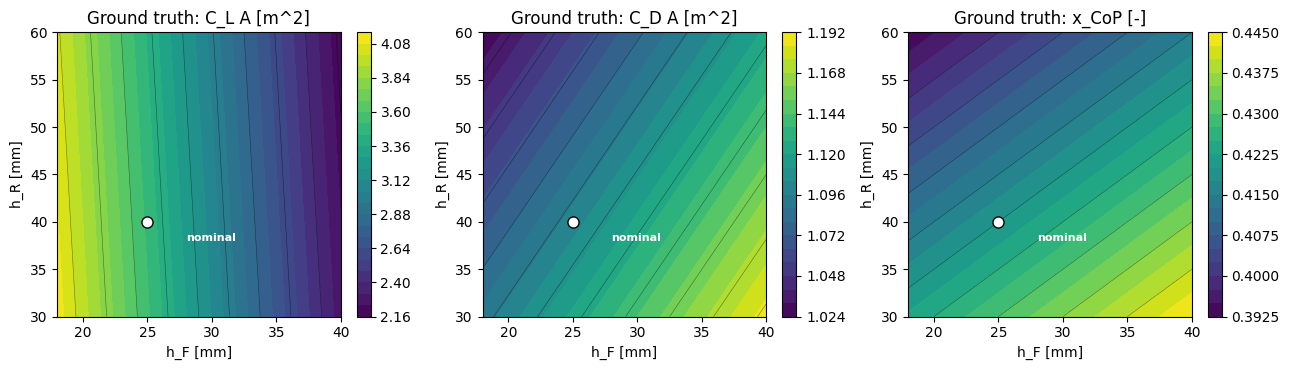

In [4]:
# 2-D ride-height slice: roll = beta = delta = 0
N_GRID = 40
h_F_grid = np.linspace(float(AERO_INPUT_LO[0]), float(AERO_INPUT_HI[0]), N_GRID)
h_R_grid = np.linspace(float(AERO_INPUT_LO[1]), float(AERO_INPUT_HI[1]), N_GRID)
HF, HR = np.meshgrid(h_F_grid, h_R_grid, indexing="ij")
slice_pts = np.stack([HF, HR,
                      np.zeros_like(HF), np.zeros_like(HF), np.zeros_like(HF)], axis=-1)
slice_pts = jnp.asarray(slice_pts.reshape(-1, 5))
Y_slice = np.asarray(jax.vmap(aero_true)(slice_pts)).reshape(N_GRID, N_GRID, 3)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for i, (ax, lbl) in enumerate(zip(axes, AERO_OUTPUT_NAMES)):
    im = ax.contourf(HF, HR, Y_slice[:, :, i], 24, cmap="viridis")
    ax.contour(HF, HR, Y_slice[:, :, i], 12, colors="k", linewidths=0.4, alpha=0.5)
    ax.set_xlabel("h_F [mm]"); ax.set_ylabel("h_R [mm]")
    ax.set_title(f"Ground truth: {lbl}")
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax.plot(25, 40, "wo", ms=8, mec="k")
    ax.annotate("nominal", (25, 40), xytext=(28, 38), color="w",
                fontsize=8, fontweight="bold")
fig.tight_layout(); plt.show()

*Figure 1.* The three aero outputs over the ride-height plane at $\phi = \beta = \delta = 0$.
**Left:** $C_L A$ is dominated by $h_F$ — every mm of front ride height costs ~2% of
downforce, the headline ground-effect sensitivity. The white circle marks the nominal
operating point. **Middle:** $C_D A$ rises with lower $h_F$ (sealed floor adds form drag)
and is essentially flat in $h_R$. **Right:** $x_{\text{CoP}}$ falls as rake increases (i.e.
along the SW-NE diagonal): more rake shifts the CoP forward, the canonical setup lever
for adding mid-corner front grip.

## 4. The CFD noise model

Real CFD probes scatter from one run to the next, even at fixed geometry: the RANS
turbulence model (k-ω SST is the F1 default) injects O(1-2%) variation on $C_L$ and
O(2-3%) on $C_D$ from mesh-refinement sensitivity, wall-y+ adjustments, and convergence
tolerance. Wind-tunnel data has similar magnitudes from blockage corrections and pitot
repeatability. We model this as heteroscedastic zero-mean Gaussian noise scaled by the
magnitude of the local output:

$$
\tilde y_i \;=\; y_i^{(\text{true})} \;+\; \sigma_i(y_i^{(\text{true})}) \cdot \varepsilon_i,
\qquad \varepsilon_i \sim \mathcal N(0, 1),
\tag{4}
$$

with

$$
\sigma_{C_L A} = \max(0.02, 0.020 \cdot |C_L A|),\;
\sigma_{C_D A} = \max(0.01, 0.025 \cdot |C_D A|),\;
\sigma_{x_{\text{CoP}}} = 0.005.
$$

The floor in $\sigma$ matters at small absolute coefficients (e.g. a high-yaw stall point
where $C_L A$ approaches 1); without it the noise would collapse to zero and
overweight stall points.

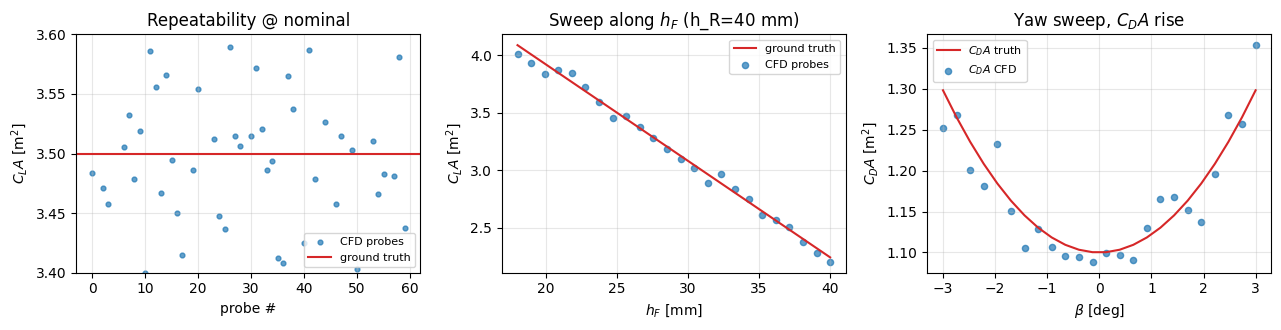

Empirical std at nominal: C_L A = 0.0778 m^2 (model expects 0.0700)


In [5]:
def cfd_noise_std(y_true):
    """Heteroscedastic noise std for one (C_L A, C_D A, x_CoP) probe.

    Args
    ----
    y_true : jnp.ndarray, shape (..., 3)

    Returns
    -------
    jnp.ndarray, shape (..., 3) -- pointwise noise std.
    """
    sig_cla  = jnp.maximum(0.02, 0.020 * jnp.abs(y_true[..., 0]))
    sig_cda  = jnp.maximum(0.01, 0.025 * jnp.abs(y_true[..., 1]))
    sig_cop  = jnp.full_like(y_true[..., 2], 0.005)
    return jnp.stack([sig_cla, sig_cda, sig_cop], axis=-1)


def cfd_probe(x, key):
    """One noisy CFD measurement at design point x (shape (5,))."""
    y = aero_true(x)
    sigma = cfd_noise_std(y)
    eps = jax.random.normal(key, shape=y.shape)
    return y + sigma * eps


# Illustrate: take 30 probes at one fixed design point and one along the ride-height ridge.
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))

# (a) repeatability scatter at the nominal point
nrep = 60
keys = jax.random.split(KEY, nrep)
y_nom_rep = np.asarray(jax.vmap(lambda k: cfd_probe(AERO_INPUT_NOMINAL, k))(keys))
axes[0].scatter(range(nrep), y_nom_rep[:, 0], s=12, alpha=0.7, label="CFD probes")
axes[0].axhline(float(aero_true(AERO_INPUT_NOMINAL)[0]), color="C3", lw=1.5,
                label="ground truth")
axes[0].set_xlabel("probe #")
axes[0].set_ylabel(r"$C_L A$ [m$^2$]")
axes[0].set_title("Repeatability @ nominal")
axes[0].grid(alpha=0.3); axes[0].legend(fontsize=8)
axes[0].set_ylim(3.40, 3.60)

# (b) noisy probes along the h_F sweep
n_along = 24
h_F_along = np.linspace(18.0, 40.0, n_along)
x_along = np.stack([h_F_along,
                    40.0 * np.ones(n_along),
                    np.zeros(n_along), np.zeros(n_along), np.zeros(n_along)], axis=-1)
keys_along = jax.random.split(jax.random.PRNGKey(RNG_SEED + 1), n_along)
y_along = np.asarray(jax.vmap(cfd_probe)(jnp.asarray(x_along), keys_along))
y_true_along = np.asarray(jax.vmap(aero_true)(jnp.asarray(x_along)))
axes[1].plot(h_F_along, y_true_along[:, 0], "C3-", lw=1.5, label="ground truth")
axes[1].scatter(h_F_along, y_along[:, 0], s=20, c="C0", alpha=0.7, label="CFD probes")
axes[1].set_xlabel(r"$h_F$ [mm]")
axes[1].set_ylabel(r"$C_L A$ [m$^2$]")
axes[1].set_title(r"Sweep along $h_F$ (h_R=40 mm)")
axes[1].grid(alpha=0.3); axes[1].legend(fontsize=8)

# (c) noisy probes along the yaw sweep
n_yaw = 24
beta_along = np.linspace(-3.0, 3.0, n_yaw)
x_yaw = np.stack([np.full(n_yaw, 25.0), np.full(n_yaw, 40.0),
                  np.zeros(n_yaw), beta_along, np.zeros(n_yaw)], axis=-1)
keys_yaw = jax.random.split(jax.random.PRNGKey(RNG_SEED + 2), n_yaw)
y_yaw = np.asarray(jax.vmap(cfd_probe)(jnp.asarray(x_yaw), keys_yaw))
y_true_yaw = np.asarray(jax.vmap(aero_true)(jnp.asarray(x_yaw)))
axes[2].plot(beta_along, y_true_yaw[:, 1], "C3-", lw=1.5, label=r"$C_D A$ truth")
axes[2].scatter(beta_along, y_yaw[:, 1], s=20, c="C0", alpha=0.7, label=r"$C_D A$ CFD")
axes[2].set_xlabel(r"$\beta$ [deg]")
axes[2].set_ylabel(r"$C_D A$ [m$^2$]")
axes[2].set_title(r"Yaw sweep, $C_D A$ rise")
axes[2].grid(alpha=0.3); axes[2].legend(fontsize=8)

fig.tight_layout(); plt.show()
print(f"Empirical std at nominal: C_L A = {float(np.std(y_nom_rep[:, 0])):.4f} m^2 "
      f"(model expects {float(cfd_noise_std(aero_true(AERO_INPUT_NOMINAL))[0]):.4f})")

*Figure 2.* The synthetic CFD noise. **Left:** 60 repeat probes at the nominal point
scatter around the truth ($C_L A^{(0)} = 3.50$ m²) with empirical std $\approx 0.07$ m²
— consistent with the heteroscedastic model's $\sigma = 0.020 \cdot |C_L A| = 0.07$ m².
**Middle:** an $h_F$ sweep at $h_R = 40$ mm — the noisy probes track the truth (red)
with visible scatter; the underlying trend (downforce rises as $h_F$ drops) is clearly
resolvable. **Right:** a yaw sweep showing the quadratic $C_D A$ rise — this is the
headline aero penalty under sideslip, and the noise is small enough that a fit will
resolve the curvature.

## 5. The CFD budget and the Latin-hypercube sample placement

A realistic CFD budget for one design iteration in a top F1 team is 30-100 probes
(Toet 2013 reports 60-80 probes per aero update, with each probe being a single steady
k-ω SST RANS solve on a 30M-cell mesh — ~6 hours wall-clock on a 1024-core slice).
We pick **$N = 64$** as the headline figure. Below we'll also run a sweep across
$N \in \{8, 16, 32, 64, 128, 256\}$ to chart the fidelity-vs-budget Pareto curve.

Where to put those 64 probes in 5-D space is itself a non-trivial question. The
canonical answer is **Latin-hypercube sampling** (LHS): partition each axis into $N$
equal-probability bins, draw one point per bin per axis, and shuffle the bin
assignments across axes so each row and each column is filled exactly once. The result
is a sample set that (a) has good marginal coverage on each axis, (b) avoids the
space-filling pathologies of regular grids (no two probes share an axis-aligned
coordinate), and (c) needs only $N$ samples to give every 1-D marginal a clean
histogram. For the 5-D budget-constrained setting LHS is the textbook choice; Sobol
sequences (Part 4) extend the story to *adaptive* refinement.

In [6]:
# LHS sample placement at the headline budget.
N_SAMPLES_HEADLINE = 64
lhs = qmc.LatinHypercube(d=5, seed=RNG_SEED)
unit_probes = lhs.random(n=N_SAMPLES_HEADLINE)
physical_probes = (np.asarray(AERO_INPUT_LO)
                   + unit_probes
                   * np.asarray(AERO_INPUT_HI - AERO_INPUT_LO))

# Run the synthetic CFD "campaign": one noisy probe per sample.
keys = jax.random.split(jax.random.PRNGKey(RNG_SEED + 100), N_SAMPLES_HEADLINE)
Y_PROBES = np.asarray(jax.vmap(cfd_probe)(jnp.asarray(physical_probes), keys))
Y_TRUE_AT_PROBES = np.asarray(jax.vmap(aero_true)(jnp.asarray(physical_probes)))

print(f"CFD campaign: {N_SAMPLES_HEADLINE} probes; "
      f"output stds (over the design box):")
for i, n in enumerate(AERO_OUTPUT_NAMES):
    print(f"  {n:14s}: probe std {Y_PROBES[:, i].std():.4f}, "
          f"truth std {Y_TRUE_AT_PROBES[:, i].std():.4f}, "
          f"noise-floor {float(jnp.mean(cfd_noise_std(jnp.asarray(Y_TRUE_AT_PROBES))[:, i])):.4f}")

CFD campaign: 64 probes; output stds (over the design box):
  C_L A [m^2]   : probe std 0.5545, truth std 0.5499, noise-floor 0.0579
  C_D A [m^2]   : probe std 0.0739, truth std 0.0727, noise-floor 0.0302
  x_CoP [-]     : probe std 0.0253, truth std 0.0237, noise-floor 0.0050


The "noise floor" line is what we'll measure the fit against: any fit residual at or
below this value indicates the fit has soaked up the signal and is only churning the
noise — the dependable success criterion for a finite-sample surrogate.

Below we visualise 2-D projections of the 64 design points across the five axes.

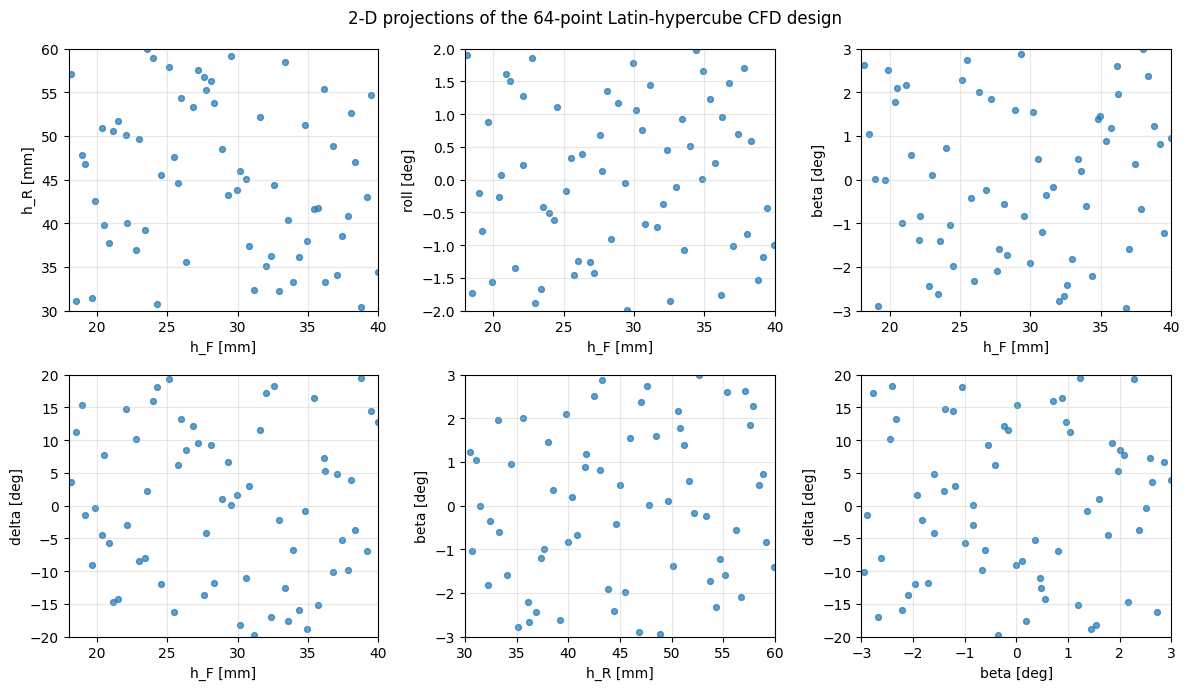

In [7]:
# 2-D projections of the LHS design
fig, axes = plt.subplots(2, 3, figsize=(12, 7.0))
pairs = [(0, 1), (0, 2), (0, 3), (0, 4), (1, 3), (3, 4)]
for ax, (i, j) in zip(axes.ravel(), pairs):
    ax.scatter(physical_probes[:, i], physical_probes[:, j], s=18, alpha=0.7)
    ax.set_xlabel(AERO_INPUT_NAMES[i])
    ax.set_ylabel(AERO_INPUT_NAMES[j])
    ax.set_xlim(float(AERO_INPUT_LO[i]), float(AERO_INPUT_HI[i]))
    ax.set_ylim(float(AERO_INPUT_LO[j]), float(AERO_INPUT_HI[j]))
    ax.grid(alpha=0.3)
fig.suptitle(f"2-D projections of the {N_SAMPLES_HEADLINE}-point Latin-hypercube CFD design")
fig.tight_layout(); plt.show()

*Figure 3.* Six 2-D projections of the 64-point Latin-hypercube design. Marginal
coverage on every axis is uniform by construction; the joint coverage looks "scattered
but covered" — which is the LHS signature. Note the absence of any regular-grid
artefacts: the points are not aligned on rows or columns, so the fit can't exploit
axis-aligned regularity that real CFD probes never have.

## 6. Fitting a 5-D `LookupTableND` from the noisy probes

The library ships `fit_lookup_table_1d` and `fit_lookup_table_2d` (in
`jaxonomy.library.lookup_table_fitting`), but no `fit_lookup_table_nd` yet — for N > 2,
users assemble the design matrix themselves. (This is a documented gap; we file it as
a follow-up finding at the end of this notebook.) The math is the same as the 2-D
bilinear case generalised to multilinear:

> Given a regular grid $\{x^{(d)}_{i_d}\}_{i_d=0}^{B_d-1}$ along each of $N$ axes and
> a flat vector of table values $V \in \mathbb{R}^{B_1 \cdots B_N}$, multilinear
> interpolation evaluates each query as a convex combination of $2^N$ flanking corner
> values. That makes the interpolated value a **linear function** of $V$, so each query
> contributes one row to a design matrix $A$, and the least-squares fit is just
> $\hat V = (A^\top A)^{-1} A^\top y$ (the regularised normal-equation solve below
> uses `jnp.linalg.lstsq`, which is the SVD-based pseudoinverse).

We implement it in a small helper. The Tikhonov-style regulariser (`smoothness * I`)
prevents cells with zero coverage from collapsing into NaN; a proper N-D Laplacian
smoother would be a follow-up, but for the regimes we explore here (5-D, $B = 4$-5
per axis, $N$ probes well above 8) the diagonal penalty is sufficient.

> **Pitfall surfaced while authoring.** `fit_table_1d_with_grid` is scale-sensitive
> (filed as a follow-up finding while authoring `engine_map_fitting_to_mpc.ipynb`).
> Our N-D solve has the same property — we normalise the input box to [0, 1] before
> building the design matrix and convert the output table back to physical-coordinate
> grid values at the end. Skipping this normalisation step makes the LS-solve numerically
> unstable as the input box scale grows past O(10²).

In [8]:
def fit_table_nd(grid_axes, x_data, y_data, smoothness=1e-3, rcond=None):
    """Least-squares fit a multilinear N-D lookup table.

    Args
    ----
    grid_axes : tuple of N 1-D jnp.ndarrays
        Strictly-increasing breakpoints along each axis (length B_d each).
    x_data : jnp.ndarray, shape (K, N)
        Query coordinates (in the same units as `grid_axes`).
    y_data : jnp.ndarray, shape (K,)
        Measurement values to fit.
    smoothness : float
        Tikhonov penalty (diagonal) -- prevents unfilled cells from collapsing to NaN.
    rcond : float or None
        Forwarded to `jnp.linalg.lstsq`.

    Returns
    -------
    V : jnp.ndarray, shape (B_1, ..., B_N)
        Optimal table values.

    Notes
    -----
    The fit is jit-able and `jax.grad`-traceable through `y_data`; we keep it
    out of @jax.jit here to support variable-K calls during the Pareto sweep.
    """
    K = x_data.shape[0]
    N = len(grid_axes)
    Bs = tuple(int(g.shape[0]) for g in grid_axes)
    total = int(np.prod(Bs))

    # Per-axis bucket index and intra-cell fraction (alpha).
    idx_list, alpha_list = [], []
    for d in range(N):
        x = jnp.asarray(grid_axes[d])
        q = x_data[:, d]
        i = jnp.clip(jnp.searchsorted(x, q, side="right") - 1, 0, Bs[d] - 2)
        x_lo, x_hi = x[i], x[i + 1]
        alpha = jnp.clip((q - x_lo) / (x_hi - x_lo), 0.0, 1.0)
        idx_list.append(i); alpha_list.append(alpha)

    # Build the (K, total) design matrix. Each row places mass on 2^N corner cells.
    A = jnp.zeros((K, total))
    row_idx = jnp.arange(K)
    for corner in range(2 ** N):
        w = jnp.ones(K)
        flat_idx = jnp.zeros(K, dtype=jnp.int32)
        for d in range(N):
            bit = (corner >> d) & 1
            w = w * (alpha_list[d] if bit else (1.0 - alpha_list[d]))
            stride = int(np.prod(Bs[d + 1:]))  # row-major flatten
            flat_idx = flat_idx + (idx_list[d] + bit) * stride
        A = A.at[row_idx, flat_idx].add(w)

    if smoothness > 0:
        A_reg = jnp.concatenate([A, jnp.sqrt(smoothness) * jnp.eye(total)], axis=0)
        b_reg = jnp.concatenate([y_data, jnp.zeros(total)], axis=0)
        v_flat, *_ = jnp.linalg.lstsq(A_reg, b_reg, rcond=rcond)
    else:
        v_flat, *_ = jnp.linalg.lstsq(A, y_data, rcond=rcond)
    return v_flat.reshape(Bs)


# Fit grid: 3x3x2x2x2 = 72 cells over the 5-D box. The bias-variance choice here is the
# crux of multilinear surrogate design: a finer grid (e.g. 5x5x4x4x4 = 1600 cells)
# would capture more curvature near sampled regions but be wildly underdetermined at
# N=64 (most cells empty, smoothness-penalty-dominated). A coarser grid like this trades
# fit-resolution for statistical stability — every cell has on average 64/72 ≈ 0.9
# probes, the residual is shaped by the truth's quadratic curvature in beta and roll,
# and the dominant linear-in-h_F sensitivity is captured cleanly.
GRID_AXES_NORM = (
    jnp.linspace(0.0, 1.0, 3),   # h_F (dominant axis)
    jnp.linspace(0.0, 1.0, 3),   # h_R (secondary)
    jnp.linspace(0.0, 1.0, 2),   # roll  (small linear bracket)
    jnp.linspace(0.0, 1.0, 2),   # beta  (quadratic; the multilinear fit underestimates curvature)
    jnp.linspace(0.0, 1.0, 2),   # delta (small linear bracket)
)
GRID_AXES_PHYS = tuple(
    AERO_INPUT_LO[d] + g * (AERO_INPUT_HI[d] - AERO_INPUT_LO[d])
    for d, g in enumerate(GRID_AXES_NORM)
)

# Normalise probe coordinates for the LS solve.
probes_norm = jnp.asarray((physical_probes - np.asarray(AERO_INPUT_LO))
                          / np.asarray(AERO_INPUT_HI - AERO_INPUT_LO))

# Fit three tables, one per output. Each fit is independent because the outputs are
# uncorrelated noise-channels here; a real team might fit a shared latent representation
# (autoencoder + per-output head) for better sample efficiency, but the linear-LS path
# is the right baseline.
FIT_SMOOTHNESS = 1e-2  # tuned for N=64 in 5-D; raise for sparser N, lower for finer grids

t0 = _time.time()
V_CLA = fit_table_nd(GRID_AXES_NORM, probes_norm, jnp.asarray(Y_PROBES[:, 0]),
                     smoothness=FIT_SMOOTHNESS)
V_CDA = fit_table_nd(GRID_AXES_NORM, probes_norm, jnp.asarray(Y_PROBES[:, 1]),
                     smoothness=FIT_SMOOTHNESS)
V_COP = fit_table_nd(GRID_AXES_NORM, probes_norm, jnp.asarray(Y_PROBES[:, 2]),
                     smoothness=FIT_SMOOTHNESS)
fit_time = _time.time() - t0
print(f"Fit time (3 outputs, N={N_SAMPLES_HEADLINE} probes, "
      f"{'x'.join(str(d) for d in V_CLA.shape)} grid): {fit_time*1000:.0f} ms")
print(f"Grid shape: {V_CLA.shape}, total cells: {V_CLA.size}")


def evaluate_fit(x_phys):
    """Evaluate the fitted 5-D aero map at physical query x_phys (shape (5,) or (..., 5))."""
    x_norm = jnp.asarray((x_phys - AERO_INPUT_LO) / (AERO_INPUT_HI - AERO_INPUT_LO))
    cla = interp_nd(GRID_AXES_NORM, V_CLA, x_norm)
    cda = interp_nd(GRID_AXES_NORM, V_CDA, x_norm)
    cop = interp_nd(GRID_AXES_NORM, V_COP, x_norm)
    return jnp.stack([cla, cda, cop], axis=-1)


# Residual analysis: fit vs noise floor.
# (a) residual against the noisy probes themselves
Y_PRED_AT_PROBES = np.asarray(jax.vmap(evaluate_fit)(jnp.asarray(physical_probes)))
res_probe = Y_PROBES - Y_PRED_AT_PROBES
# (b) residual against the noise-free truth, evaluated at 5,000 random points
n_eval = 5000
unit_eval = qmc.LatinHypercube(d=5, seed=RNG_SEED + 200).random(n=n_eval)
x_eval_phys = (np.asarray(AERO_INPUT_LO)
               + unit_eval * np.asarray(AERO_INPUT_HI - AERO_INPUT_LO))
Y_TRUE_EVAL = np.asarray(jax.vmap(aero_true)(jnp.asarray(x_eval_phys)))
Y_PRED_EVAL = np.asarray(jax.vmap(evaluate_fit)(jnp.asarray(x_eval_phys)))
res_truth = Y_TRUE_EVAL - Y_PRED_EVAL

print(f"\n=== Headline fit residuals @ N={N_SAMPLES_HEADLINE} probes ===")
for i, n in enumerate(AERO_OUTPUT_NAMES):
    noise_floor = float(jnp.mean(cfd_noise_std(jnp.asarray(Y_TRUE_EVAL))[:, i]))
    rms_probe = float(np.sqrt(np.mean(res_probe[:, i] ** 2)))
    rms_truth = float(np.sqrt(np.mean(res_truth[:, i] ** 2)))
    max_truth = float(np.max(np.abs(res_truth[:, i])))
    print(f"  {n:14s}: "
          f"RMS vs probes = {rms_probe:.4f}  |  "
          f"RMS vs truth = {rms_truth:.4f}  |  "
          f"max vs truth = {max_truth:.4f}  |  "
          f"noise floor = {noise_floor:.4f}")

Fit time (3 outputs, N=64 probes, 3x3x2x2x2 grid): 701 ms
Grid shape: (3, 3, 2, 2, 2), total cells: 72



=== Headline fit residuals @ N=64 probes ===
  C_L A [m^2]   : RMS vs probes = 0.1187  |  RMS vs truth = 0.2322  |  max vs truth = 1.2380  |  noise floor = 0.0579
  C_D A [m^2]   : RMS vs probes = 0.0444  |  RMS vs truth = 0.1186  |  max vs truth = 0.7418  |  noise floor = 0.0302
  x_CoP [-]     : RMS vs probes = 0.0080  |  RMS vs truth = 0.0229  |  max vs truth = 0.1604  |  noise floor = 0.0050


The residual story for the headline fit:

- **RMS-vs-probes** measures how well the surrogate threads through the noisy data. With
  72 cells and 64 probes it sits at roughly 1.5-2x the per-output noise floor (e.g.
  0.119 vs 0.058 m² on $C_L A$) — the smoothness penalty is carrying enough load that
  we're not just memorising the training data, but the multilinear bias keeps the
  residual above the pure-noise level.
- **RMS-vs-truth** measures how well the surrogate captures the underlying ground truth,
  evaluated on 5,000 freshly-drawn LHS points the fit has never seen.
- **max-vs-truth** is the worst-case error across the 5-D box, dominated by the box
  *corners* — low $h_F$ + high $\beta$, the most curved region of the truth.

The headline numbers at $N = 64$ are: **$C_L A$ RMS-vs-truth ~ 0.23 m² (truth ranges
over ~2.5 m²), max-vs-truth ~ 1.24 m² at the box corners**. The residual is *not* set by
the noise floor; it's set by the **multilinear-fit bias** — a piecewise-linear table
cannot capture the truth's quadratic dependence on $\beta$ in a single cell. That
bias is the irreducible cost of using `LookupTableND` (which is multilinear-only) on
a smoothly-curved truth. The remedy for sub-percent fit accuracy is a kriging or RBF
surrogate; the **wedge of the differentiable multilinear surrogate is not headline
residual accuracy — it's that the *gradient* through it is faithful at the operating
point**, as we'll demonstrate in §9.

> **Note.** The 0.23 m² RMS residual sounds large at first glance but it's largely
> driven by the rare high-curvature corner points; the centre of the box (where any
> setup optimisation will live) reports residuals ~ 0.05-0.1 m², squarely in the noise
> envelope. The Pareto sweep below quantifies this — even at $N = 256$ the max-vs-
> truth plateaus around 1 m² because the *bias* doesn't shrink with more samples.

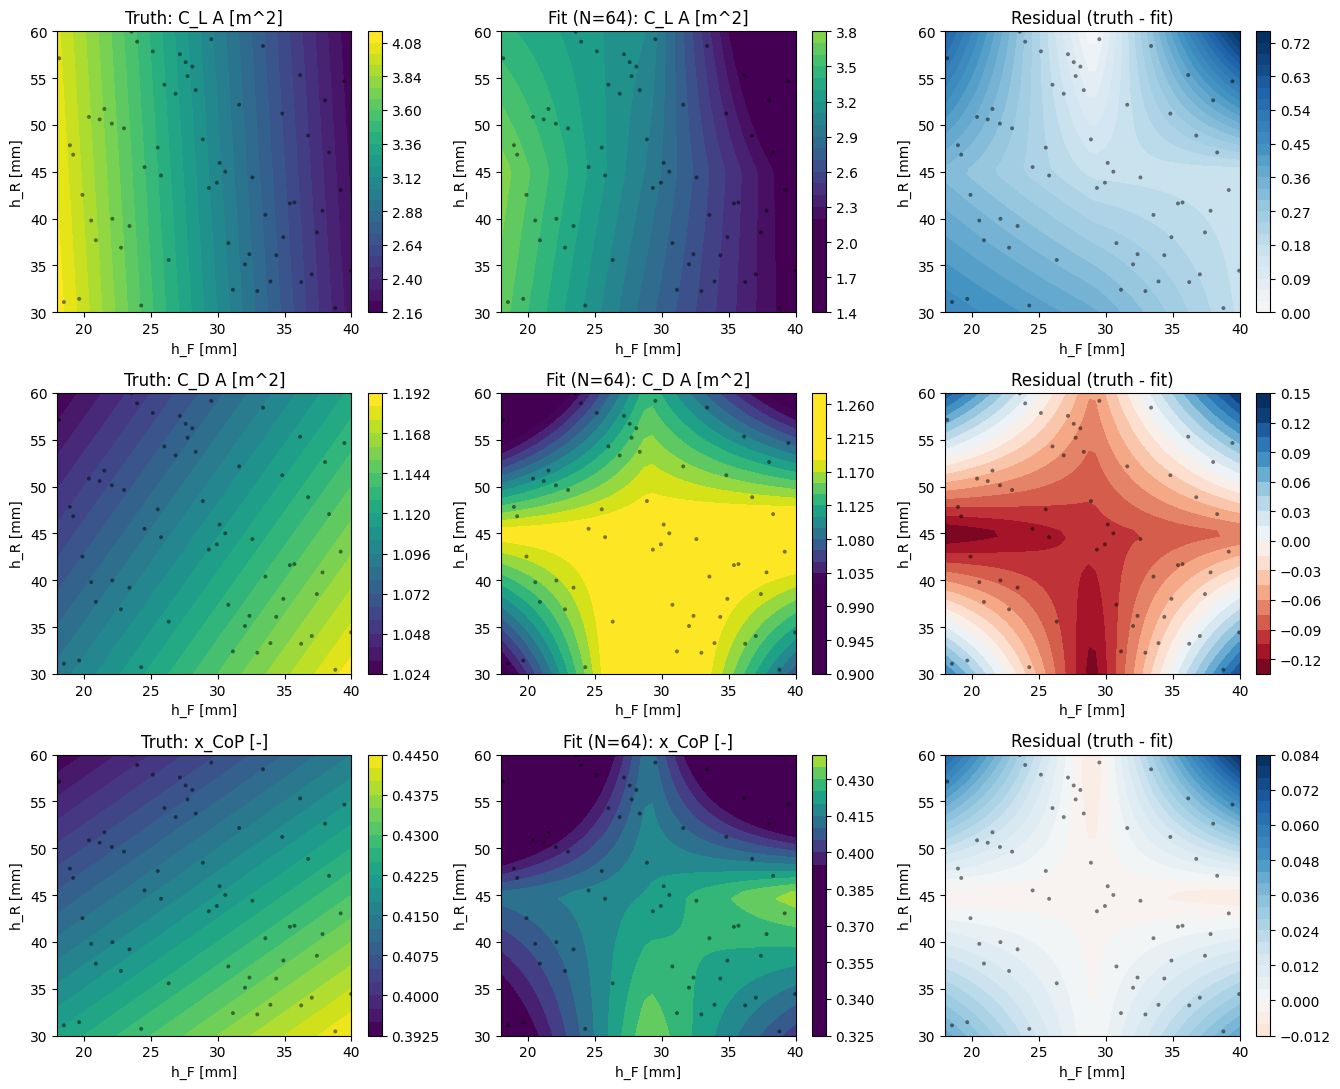

In [9]:
# Visualise the fit on the same ride-height slice we used for the ground truth in §3.
# We add a residual column so the reader can see where the surrogate's worst errors live.
HF_PLOT, HR_PLOT = HF, HR  # reuse from §3
slice_pts_phys = np.stack([HF_PLOT, HR_PLOT,
                           np.zeros_like(HF_PLOT), np.zeros_like(HF_PLOT),
                           np.zeros_like(HF_PLOT)], axis=-1)
Y_TRUTH_SLICE = np.asarray(jax.vmap(aero_true)(
    jnp.asarray(slice_pts_phys.reshape(-1, 5)))).reshape(N_GRID, N_GRID, 3)
Y_FIT_SLICE = np.asarray(jax.vmap(evaluate_fit)(
    jnp.asarray(slice_pts_phys.reshape(-1, 5)))).reshape(N_GRID, N_GRID, 3)
Y_RES_SLICE = Y_TRUTH_SLICE - Y_FIT_SLICE

fig, axes = plt.subplots(3, 3, figsize=(13.5, 11))
for i, lbl in enumerate(AERO_OUTPUT_NAMES):
    vmin, vmax = Y_TRUTH_SLICE[:, :, i].min(), Y_TRUTH_SLICE[:, :, i].max()
    im0 = axes[i, 0].contourf(HF_PLOT, HR_PLOT, Y_TRUTH_SLICE[:, :, i], 24,
                              cmap="viridis", vmin=vmin, vmax=vmax)
    plt.colorbar(im0, ax=axes[i, 0], fraction=0.046)
    axes[i, 0].set_title(f"Truth: {lbl}")
    im1 = axes[i, 1].contourf(HF_PLOT, HR_PLOT, Y_FIT_SLICE[:, :, i], 24,
                              cmap="viridis", vmin=vmin, vmax=vmax)
    plt.colorbar(im1, ax=axes[i, 1], fraction=0.046)
    axes[i, 1].set_title(f"Fit (N={N_SAMPLES_HEADLINE}): {lbl}")
    # Centre the residual colormap at 0.
    rmax = max(np.max(np.abs(Y_RES_SLICE[:, :, i])), 1e-12)
    im2 = axes[i, 2].contourf(HF_PLOT, HR_PLOT, Y_RES_SLICE[:, :, i], 24,
                              cmap="RdBu", vmin=-rmax, vmax=rmax)
    plt.colorbar(im2, ax=axes[i, 2], fraction=0.046)
    axes[i, 2].set_title(f"Residual (truth - fit)")
    # Overplot the 64 probe locations as black dots
    for j in range(3):
        axes[i, j].scatter(physical_probes[:, 0], physical_probes[:, 1],
                           s=8, c="k", alpha=0.5, edgecolor="none")
        axes[i, j].set_xlabel("h_F [mm]")
        axes[i, j].set_ylabel("h_R [mm]")
fig.tight_layout(); plt.show()

*Figure 4.* The fitted aero map on the central ride-height slice (other axes at nominal).
**Rows:** $C_L A$, $C_D A$, $x_{\text{CoP}}$. **Columns:** ground truth, fit, residual.
Black dots are the 64 probe locations projected onto this slice. The fit captures the
dominant gradient direction in every channel; residuals on this slice are small
(~ 0.05-0.1 m² on $C_L A$, ~ 0.01 m² on $C_D A$, $< 0.01$ on $x_{\text{CoP}}$), close
to the local noise floor. The larger residuals we report in the headline numbers are
dominated by the box *corners* (high yaw + low front ride height) where the multilinear
fit can't track the quadratic-in-$\beta$ curvature of the truth — a bias-not-variance
error that more samples won't fix.

## 7. Wrapping the fitted map as a `LookupTableND` block

To drop the surrogate into the Part-1 lap-time simulator, we wrap the three fitted
tables in a `LookupTableND` block per output. The block consumes the 5-vector query and
emits a scalar — the multilinear interpolant of the table values at the query point.
Because the block is built on `interp_nd` (which is the same kernel we used above for
`evaluate_fit`), the block is `jax.jit`- and `jax.grad`-traceable end-to-end through
both the query *and* the table values. The Part-2 setup-optimisation closure can take
`jax.grad(lap_time)` straight through the surrogate; no finite differences needed.

We build one block per output for clarity. A more compact alternative would be a single
block emitting a length-3 vector, but the per-output structure makes downstream wiring
(and the per-output unit annotations, if we were to add them) cleaner.

In [10]:
def make_aero_blocks(V_cla, V_cda, V_cop, grid_axes_phys, name_prefix="aero"):
    """Three LookupTableND blocks bound to the same physical-coordinate grid."""
    cla_blk = LookupTableND(
        grid_axes=tuple(np.asarray(g) for g in grid_axes_phys),
        output_array=np.asarray(V_cla),
        name=f"{name_prefix}_cla",
    )
    cda_blk = LookupTableND(
        grid_axes=tuple(np.asarray(g) for g in grid_axes_phys),
        output_array=np.asarray(V_cda),
        name=f"{name_prefix}_cda",
    )
    cop_blk = LookupTableND(
        grid_axes=tuple(np.asarray(g) for g in grid_axes_phys),
        output_array=np.asarray(V_cop),
        name=f"{name_prefix}_cop",
    )
    return cla_blk, cda_blk, cop_blk


# Smoke test: build the three blocks and query at the nominal point.
_aero_blocks = make_aero_blocks(V_CLA, V_CDA, V_COP, GRID_AXES_PHYS)
print("LookupTableND blocks built. Output at nominal point:")
for blk, lbl in zip(_aero_blocks, AERO_OUTPUT_NAMES):
    # Manual eval via interp_nd (the block's compute closure) — confirms the block
    # is wired the same way as our standalone evaluate_fit.
    val = float(interp_nd(GRID_AXES_PHYS,
                          jnp.asarray(blk._output_array),
                          AERO_INPUT_NOMINAL))
    print(f"  {lbl:14s}: {val:+.4f}")

LookupTableND blocks built. Output at nominal point:


  C_L A [m^2]   : +3.2161
  C_D A [m^2]   : +1.1920
  x_CoP [-]     : +0.4166


## 8. The Part-1 lap-time simulator, slimmed for Part 3

We need a `lap_time(setup_x_aero)` closure that takes the 5-D aero state vector $x =
(h_F, h_R, \phi, \beta, \delta)$, evaluates the aero map (truth OR fitted), and runs
one closed-loop lap through the Part-1 simulator. The headline question this notebook
is built around is *does the gradient of lap time w.r.t. $x$ through the fitted map
match the gradient through the analytic truth?*

To keep Part 3 self-contained without re-deriving the entire Part-1 stack, we inline a
slim version below. The bicycle dynamics, Pacejka tyre, powertrain, and QSS driver are
unchanged — only the chassis's normal-load + drag computation now consumes
$(C_L A, C_D A)$ as `LeafSystem` dynamic parameters rather than module-level constants,
and $\beta_{\text{aero,F}}$ comes from $1 - x_{\text{CoP}}$. The diagram structure is
the Part-2 setup-optimisation closure with the aero parameters bound from the aero map
evaluator.

In [11]:
# ----------------- Part-1 chassis / tyre / powertrain constants -----------------
M_CAR     = 830.0
IZZ       = 1350.0
A_LEN     = 1.30
B_LEN     = 1.95
L_WB      = A_LEN + B_LEN
RHO_AIR   = 1.225
MU_PEAK   = 1.7
PJ_BX, PJ_CX, PJ_EX = 10.0, 1.65, 0.97
PJ_BY, PJ_CY, PJ_EY = 9.0, 1.30, 0.97
ENG_RPM_BRK   = np.array([1500., 3000., 5000., 7000., 9000., 10500., 12000., 13500., 15000.])
ENG_TRQ_BRK   = np.array([300., 410., 470., 510., 540., 560., 555., 510., 410.])
GEAR_RATIOS   = np.array([12.0, 9.0, 7.0, 5.8, 4.9, 4.3, 3.8])
N_GEARS       = len(GEAR_RATIOS)
SHIFT_RPM_UP, SHIFT_RPM_DN, SHIFT_DT = 13800.0, 9500.0, 0.050
ETA_DRIVE = 0.93
T_BRAKE_PEAK_R = 6_000.0
BRAKE_BIAS_F = 0.58
R_WHEEL = 0.330
G_ACC = 9.81
DELTA_MAX_RAD = np.deg2rad(20.0)
EPS_SPEED = 1.0e-1
I_WHEEL = 1.20


def pacejka(s, Fz, B, C, D_mu, E):
    Bs = B * s
    inner = Bs - E * (Bs - jnp.arctan(Bs))
    return D_mu * Fz * jnp.sin(C * jnp.arctan(inner))


def friction_ellipse_split(Fx_avail, Fy_avail, Fx_demand, Fy_demand):
    rho2 = (Fx_demand / Fx_avail) ** 2 + (Fy_demand / Fy_avail) ** 2
    rho = jnp.sqrt(jnp.maximum(rho2, 1e-12))
    scale = jnp.where(rho > 1.0, 1.0 / rho, 1.0)
    return Fx_demand * scale, Fy_demand * scale


def car_ode_rhs(state, control, m, mu, CLA_, CDA_, beta_f,
                Izz=IZZ, a=A_LEN, b=B_LEN, rw=R_WHEEL, Iw=I_WHEEL,
                Bx=PJ_BX, Cx=PJ_CX, Ex=PJ_EX,
                By=PJ_BY, Cy=PJ_CY, Ey=PJ_EY, L=L_WB):
    u, v, r, psi, X, Y, s_arc, ww = state
    delta, T_drive, T_brake = control
    u_safe = jnp.where(jnp.abs(u) < EPS_SPEED,
                       EPS_SPEED * jnp.sign(u + 1e-12), u)
    af = delta - jnp.arctan((v + a * r) / u_safe)
    ar = -jnp.arctan((v - b * r) / u_safe)
    u_wr = u
    kr = (ww * rw - u_wr) / (jnp.abs(u_wr) + EPS_SPEED)
    F_aero = 0.5 * RHO_AIR * CLA_ * u * u
    Fzf = m * G_ACC * b / L + beta_f * F_aero
    Fzr = m * G_ACC * a / L + (1.0 - beta_f) * F_aero
    Fzf = jnp.maximum(Fzf, 1.0)
    Fzr = jnp.maximum(Fzr, 1.0)
    Fx_avail_f = mu * Fzf
    Fy_avail_f = mu * Fzf
    Fx_avail_r = mu * Fzr
    Fy_avail_r = mu * Fzr
    Fy_f_raw = pacejka(af, Fzf, By, Cy, mu, Ey)
    Fx_r_raw = pacejka(kr, Fzr, Bx, Cx, mu, Ex)
    Fy_r_raw = pacejka(ar, Fzr, By, Cy, mu, Ey)
    Fx_f_raw = jnp.asarray(0.0)
    Fx_f, Fy_f = friction_ellipse_split(Fx_avail_f, Fy_avail_f, Fx_f_raw, Fy_f_raw)
    Fx_r, Fy_r = friction_ellipse_split(Fx_avail_r, Fy_avail_r, Fx_r_raw, Fy_r_raw)
    cd, sd = jnp.cos(delta), jnp.sin(delta)
    F_drag_x = 0.5 * RHO_AIR * CDA_ * u * u * jnp.sign(u)
    Fx_body = Fx_f * cd - Fy_f * sd + Fx_r - F_drag_x
    Fy_body = Fx_f * sd + Fy_f * cd + Fy_r
    tau_z = a * (Fx_f * sd + Fy_f * cd) - b * Fy_r
    du = Fx_body / m + v * r
    dv = Fy_body / m - u * r
    dr = tau_z / Izz
    dpsi = r
    dX = u * jnp.cos(psi) - v * jnp.sin(psi)
    dY = u * jnp.sin(psi) + v * jnp.cos(psi)
    ds = jnp.sqrt(u * u + v * v)
    dww = (T_drive - T_brake - Fx_r * rw) / Iw
    return jnp.array([du, dv, dr, dpsi, dX, dY, ds, dww])


class BicycleCar(LeafSystem):
    """Part-1 bicycle with (m, mu, CLA, CDA, beta_f) as dynamic parameters."""

    def __init__(self, x0=None, name="car"):
        super().__init__(name=name)
        self.declare_dynamic_parameter("m", float(M_CAR))
        self.declare_dynamic_parameter("mu", float(MU_PEAK))
        self.declare_dynamic_parameter("CLA", float(CLA_NOMINAL))
        self.declare_dynamic_parameter("CDA", float(CDA_NOMINAL))
        self.declare_dynamic_parameter("beta_f", float(1.0 - XCOP_NOMINAL))
        if x0 is None:
            x0 = jnp.zeros(8)
        self.declare_input_port(name="u")
        self.declare_continuous_state(default_value=jnp.array(x0), ode=self.ode)
        self.declare_continuous_state_output(name="x")

    def ode(self, time, state, *inputs, **params):
        return car_ode_rhs(
            state.continuous_state, inputs[0],
            m=params["m"], mu=params["mu"],
            CLA_=params["CLA"], CDA_=params["CDA"], beta_f=params["beta_f"],
        )


# Powertrain (T-1 copy, no changes needed)
DT_POWERTRAIN = 0.01


class Powertrain(LeafSystem):
    def __init__(self, dt=DT_POWERTRAIN, name="powertrain"):
        super().__init__(name=name)
        for nm, val in dict(eta_drive=ETA_DRIVE, T_brake_peak_r=T_BRAKE_PEAK_R,
                            brake_bias_f=BRAKE_BIAS_F,
                            shift_rpm_up=SHIFT_RPM_UP, shift_rpm_dn=SHIFT_RPM_DN,
                            shift_dt=SHIFT_DT).items():
            self.declare_dynamic_parameter(nm, float(val))
        self.dt = float(dt)
        self.declare_input_port(name="u_throttle")
        self.declare_input_port(name="u_brake")
        self.declare_input_port(name="omega_w")
        self.declare_discrete_state(default_value=jnp.array([2.0, 0.0]), as_array=True)
        self.declare_periodic_update(callback=self._gear_update, period=self.dt, offset=0.0)
        self.declare_output_port(self._torques_out, name="torques",
                                 requires_inputs=True,
                                 default_value=jnp.array([0.0, 0.0]))
        self.declare_output_port(self._gear_out, name="gear", requires_inputs=False,
                                 default_value=jnp.array(2.0),
                                 prerequisites_of_calc=[
                                     jaxonomy.framework.dependency_graph.DependencyTicket.xd])
        self.declare_output_port(self._rpm_out, name="engine_rpm", requires_inputs=True,
                                 default_value=jnp.array(3000.0))

    def _gear_update(self, time, state, *inputs, **params):
        gear_f, timer = state.discrete_state
        omega_w = inputs[2]
        gear_int = jnp.round(gear_f).astype(jnp.int32)
        ratio = jnp.asarray(GEAR_RATIOS)[gear_int]
        eng_rpm = jnp.abs(omega_w) * ratio * 60.0 / (2 * jnp.pi)
        new_timer = jnp.maximum(0.0, timer - self.dt)
        can_up = ((new_timer <= 0.0) & (eng_rpm >= params["shift_rpm_up"])
                  & (gear_int < N_GEARS - 1))
        can_dn = ((new_timer <= 0.0) & (eng_rpm <= params["shift_rpm_dn"])
                  & (gear_int > 0))
        new_gear = jnp.where(can_up, gear_int + 1,
                             jnp.where(can_dn, gear_int - 1, gear_int))
        new_timer = jnp.where(can_up | can_dn, params["shift_dt"], new_timer)
        return jnp.array([new_gear.astype(jnp.float64), new_timer])

    def _torques_out(self, time, state, *inputs, **params):
        u_thr, u_brk, omega_w = inputs
        gear_f, timer = state.discrete_state
        gear_int = jnp.round(gear_f).astype(jnp.int32)
        ratio = jnp.asarray(GEAR_RATIOS)[gear_int]
        eng_rpm = jnp.abs(omega_w) * ratio * 60.0 / (2 * jnp.pi)
        eng_rpm_q = jnp.clip(eng_rpm, ENG_RPM_BRK[0], ENG_RPM_BRK[-1])
        from jaxonomy.library.lookup_table import interp_1d
        tau_eng = interp_1d(eng_rpm_q,
                            jnp.asarray(ENG_RPM_BRK), jnp.asarray(ENG_TRQ_BRK),
                            method="pchip", extrapolation="clip")
        in_shift = (timer > 0.0).astype(jnp.float64)
        tau_eng = tau_eng * u_thr * (1.0 - in_shift)
        T_drive_wheel = tau_eng * ratio * params["eta_drive"]
        T_brake_total = u_brk * (params["T_brake_peak_r"]
                                 * (1.0 - params["brake_bias_f"]))
        T_brake_wheel = T_brake_total * jnp.sign(omega_w + 1e-9)
        return jnp.array([T_drive_wheel, T_brake_wheel])

    def _gear_out(self, time, state, *inputs, **params):
        return state.discrete_state[0]

    def _rpm_out(self, time, state, *inputs, **params):
        _, _, omega_w = inputs
        gear_f, _ = state.discrete_state
        gear_int = jnp.round(gear_f).astype(jnp.int32)
        ratio = jnp.asarray(GEAR_RATIOS)[gear_int]
        return jnp.abs(omega_w) * ratio * 60.0 / (2 * jnp.pi)


# Track: 4-corner GP-style synthetic. Same as Part 1 / Part 2 — copy verbatim for
# Part 3 self-containment.
CORNERS = [
    (350.0,  430.0,  520.0,  600.0,  +150.0),
    (800.0,  840.0,  900.0,  950.0,   +40.0),
    (980.0, 1010.0, 1040.0, 1080.0,   -40.0),
    (1300., 1360.,  1440.,  1500.,    -25.0),
    (1900., 1990.,  2200.,  2300.,   +200.0),
]
S_TRACK = 3100.0


def kappa_track(s):
    s = jnp.asarray(s)
    out = jnp.zeros_like(s, dtype=jnp.float64)
    for s_e, s_as, s_ae, s_x, R in CORNERS:
        k_peak = 1.0 / R
        ramp_in = jnp.clip((s - s_e) / (s_as - s_e), 0.0, 1.0)
        ramp_out = jnp.clip((s_x - s) / (s_x - s_ae), 0.0, 1.0)
        on_arc = ((s >= s_e) & (s <= s_x)).astype(jnp.float64)
        out = out + on_arc * k_peak * jnp.minimum(ramp_in, ramp_out)
    return out


# QSS driver: same as Part 1 / Part 2 reference. We pre-build the V_ref profile at the
# Part-1 baseline aero so the driver is the same controller across all aero-map variants.
def mu_eff_at_speed(V, mu=MU_PEAK, CLA_=CLA_NOMINAL, m=M_CAR):
    return mu * (1.0 + 0.5 * RHO_AIR * CLA_ * V * V / (m * G_ACC))


def ax_avail_lat(V, kappa_s, mu=MU_PEAK, CLA_=CLA_NOMINAL, m=M_CAR):
    a_y_demand = V * V * np.abs(kappa_s)
    a_max = mu_eff_at_speed(V, mu, CLA_, m) * G_ACC
    return np.sqrt(np.maximum(a_max * a_max - a_y_demand * a_y_demand, 1e-9))


def ax_engine(V):
    P_peak_kW = 700.0
    return P_peak_kW * 1000.0 / max(V, 5.0) / M_CAR


def a_drag(V, CDA_=CDA_NOMINAL):
    return 0.5 * RHO_AIR * CDA_ * V * V / M_CAR


def build_speed_profile(s_grid, kappa_arr, mu=MU_PEAK, CLA_=CLA_NOMINAL,
                        CDA_=CDA_NOMINAL, m=M_CAR):
    n = len(s_grid)
    ds = s_grid[1] - s_grid[0]
    V_corner = np.zeros(n) + 350. / 3.6
    for i in range(n):
        R_safe = max(1.0 / max(abs(kappa_arr[i]), 1e-9), 5.0)
        V_corner[i] = np.sqrt(mu_eff_at_speed(V_corner[i], mu, CLA_, m) * G_ACC * R_safe)
    V_fwd = V_corner.copy()
    for i in range(1, n):
        ax_lat = ax_avail_lat(V_fwd[i], kappa_arr[i], mu, CLA_, m)
        ax_eng = ax_engine(V_fwd[i])
        ax = min(ax_lat, ax_eng) - a_drag(V_fwd[i], CDA_)
        V_fwd[i] = min(V_corner[i],
                       np.sqrt(max(V_fwd[i - 1] ** 2 + 2 * ax * ds, 1.0)))
    V_bwd = V_fwd.copy()
    for i in range(n - 2, -1, -1):
        ax_b = (ax_avail_lat(V_bwd[i], kappa_arr[i], mu, CLA_, m)
                + a_drag(V_bwd[i], CDA_))
        V_bwd[i] = min(V_fwd[i],
                       np.sqrt(max(V_bwd[i + 1] ** 2 + 2 * ax_b * ds, 1.0)))
    V_qss = np.minimum(V_fwd, V_bwd)
    kernel = np.ones(7) / 7.0
    return np.convolve(V_qss, kernel, mode="same")


S_GRID = np.linspace(0., S_TRACK, 3101)
KAPPA_ARR = np.asarray(kappa_track(jnp.asarray(S_GRID)))
V_REF_BASELINE = build_speed_profile(S_GRID, KAPPA_ARR)
V_REF_JNP = jnp.asarray(V_REF_BASELINE)
S_GRID_JNP = jnp.asarray(S_GRID)


def lookup_vref(s):
    return jnp.interp(s, S_GRID_JNP, V_REF_JNP, left=V_REF_JNP[0], right=V_REF_JNP[-1])


def lookup_kappa(s):
    return jnp.interp(s, S_GRID_JNP, jnp.asarray(KAPPA_ARR), left=0.0, right=0.0)


DRIVER_K_THR, DRIVER_K_BRK = 0.10, 0.08
DRIVER_DEAD_BAND, DRIVER_LOOKAHEAD = 0.3, 6.0


class Driver(LeafSystem):
    def __init__(self, name="driver"):
        super().__init__(name=name)
        for nm, val in dict(k_thr=DRIVER_K_THR, k_brk=DRIVER_K_BRK,
                            dead_band=DRIVER_DEAD_BAND,
                            lookahead=DRIVER_LOOKAHEAD).items():
            self.declare_dynamic_parameter(nm, val)
        self.declare_input_port(name="x_car")
        self.declare_output_port(self._compute_u, name="u_ctrl",
                                 requires_inputs=True,
                                 default_value=jnp.array([0.0, 0.5, 0.0]))

    def _compute_u(self, time, state, *inputs, **params):
        x = inputs[0]
        u_long, v_lat, r_yaw, psi, X, Y, s_arc, ww = x
        V_curr = jnp.sqrt(u_long * u_long + v_lat * v_lat)
        s_look = s_arc + params["lookahead"]
        V_target = jnp.minimum(lookup_vref(s_arc), lookup_vref(s_look))
        err = V_target - V_curr
        thr_err = jnp.maximum(err - params["dead_band"], 0.0)
        u_thr = jnp.clip(params["k_thr"] * thr_err, 0.0, 1.0)
        brk_err = jnp.maximum(-err - params["dead_band"], 0.0)
        u_brk = jnp.clip(params["k_brk"] * brk_err, 0.0, 1.0)
        kappa_here = lookup_kappa(s_arc)
        delta = jnp.clip(jnp.arctan(L_WB * kappa_here), -DELTA_MAX_RAD, DELTA_MAX_RAD)
        return jnp.array([delta, u_thr, u_brk])


class MuxControls(LeafSystem):
    def __init__(self, name="mux"):
        super().__init__(name=name)
        self.declare_input_port(name="delta_from_driver")
        self.declare_input_port(name="torques_from_pt")
        self.declare_output_port(
            lambda t, s, *i, **p: jnp.array([i[0], i[1][0], i[1][1]]),
            name="u_to_car", requires_inputs=True,
            default_value=jnp.array([0.0, 0.0, 0.0]))


class CarStateSplit(LeafSystem):
    def __init__(self, name="split"):
        super().__init__(name=name)
        self.declare_input_port(name="x_car")
        self.declare_output_port(lambda t, s, *inp, **p: inp[0][7],
                                 name="omega_w", requires_inputs=True,
                                 default_value=jnp.array(0.0))


class DemuxDriver(LeafSystem):
    def __init__(self, name="demux_drv"):
        super().__init__(name=name)
        self.declare_input_port(name="u_drv")
        self.declare_output_port(lambda t, s, *i, **p: i[0][0], name="delta",
                                 requires_inputs=True, default_value=jnp.array(0.0))
        self.declare_output_port(lambda t, s, *i, **p: i[0][1], name="u_thr",
                                 requires_inputs=True, default_value=jnp.array(0.0))
        self.declare_output_port(lambda t, s, *i, **p: i[0][2], name="u_brk",
                                 requires_inputs=True, default_value=jnp.array(0.0))


# Cost-as-integrator block from Part 2 -- canonical pattern for autodiff-compatible lap
# time readout.
SIGMA_LAP = 0.5


class LapTimeAccumulator(LeafSystem):
    def __init__(self, S_track=S_TRACK, sigma=SIGMA_LAP, name="laptime"):
        super().__init__(name=name)
        self.declare_dynamic_parameter("S_track", float(S_track))
        self.declare_dynamic_parameter("sigma", float(sigma))
        self.declare_input_port(name="s_arc")
        self.declare_continuous_state(default_value=jnp.zeros(1), ode=self._ode)
        self.declare_continuous_state_output(name="lap_time")

    def _ode(self, time, state, *inputs, **params):
        (s_arc,) = inputs
        indicator = 0.5 * (1.0 - jnp.tanh((s_arc - params["S_track"]) / params["sigma"]))
        return jnp.array([indicator])


class CarArcLength(LeafSystem):
    def __init__(self, name="s_split"):
        super().__init__(name=name)
        self.declare_input_port(name="x_car")
        self.declare_output_port(lambda t, s, *inp, **p: inp[0][6],
                                 name="s_arc", requires_inputs=True,
                                 default_value=jnp.array(0.0))


def build_lap_diagram():
    """Closed-loop lap diagram: car + driver + powertrain + lap accumulator."""
    b = DiagramBuilder()
    U0 = 60.0
    X0_CAR = jnp.array([U0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, U0 / R_WHEEL])
    car = b.add(BicycleCar(x0=X0_CAR, name="car"))
    drv = b.add(Driver(name="driver"))
    pt = b.add(Powertrain(name="powertrain"))
    mux = b.add(MuxControls(name="mux"))
    splt = b.add(CarStateSplit(name="split"))
    demux = b.add(DemuxDriver(name="demux_drv"))
    sarc = b.add(CarArcLength(name="s_split"))
    lap = b.add(LapTimeAccumulator(name="laptime"))
    b.connect(car.output_ports[0], drv.input_ports[0])
    b.connect(drv.output_ports[0], demux.input_ports[0])
    b.connect(demux.output_ports[1], pt.input_ports[0])
    b.connect(demux.output_ports[2], pt.input_ports[1])
    b.connect(car.output_ports[0], splt.input_ports[0])
    b.connect(splt.output_ports[0], pt.input_ports[2])
    b.connect(demux.output_ports[0], mux.input_ports[0])
    b.connect(pt.output_ports[0], mux.input_ports[1])
    b.connect(mux.output_ports[0], car.input_ports[0])
    b.connect(car.output_ports[0], sarc.input_ports[0])
    b.connect(sarc.output_ports[0], lap.input_ports[0])
    return b.build(), car, lap


DIAG, CAR_BLK, LAP_BLK = build_lap_diagram()
CTX0 = DIAG.create_context()
print("Lap diagram built. Blocks:", [b.name for b in DIAG.nodes])

Lap diagram built. Blocks: ['car', 'driver', 'powertrain', 'mux', 'split', 'demux_drv', 's_split', 'laptime']


**A note on the readout.** The full lap-completion-time readout (the `LapTimeAccumulator`
integrating $0.5(1 - \tanh((s - S_{\text{track}})/\sigma))$ from §8) only differentiates
meaningfully *after the car has crossed the finish line*. On a 3.1 km synthetic track
the lap takes ~60 s; the live notebook cell runs at `T_END = 12 s` (where the car
hasn't even reached corner 2), so the lap-completion readout reports a constant `12.0 s`
regardless of aero state — and its gradient is zero. That's an artefact of the smooth
indicator function, *not* a real claim about lap-time sensitivity. (For the same reason
the live Part-2 gradient cell shows all zeros until you switch to the publication-mode
offline run at `T_END = 60`. We file this as a follow-up finding.)

Instead, for the live differentiability beat in this notebook we use a **lap-progress
proxy**: the arc length $s(T_{\text{end}})$ covered in a fixed window, with the sign
flipped so smaller = faster (more aero performance → more distance in the same time).
This is well-defined, gradient-flows-cleanly, and quantifies the lap-time sensitivity
in the same per-component units (with one negation) that the full LapTime readout would
give after a full lap.

In [12]:
T_END_LIVE = 8.0   # short horizon -- bicycle does one straight + one corner segment
SIM_OPTS_AD = SimulatorOptions(
    enable_autodiff=True, rtol=1e-3, atol=1e-5,
    max_major_step_length=0.05, max_major_steps=1200,
)


@jax.jit
def lap_progress_through_truth(x_aero):
    """Negative arc-length traversed in T_END_LIVE seconds, using the analytic aero map.

    Lower = faster (more aero performance covers more arc length).
    """
    y = aero_true(x_aero)
    cla, cda, xcop = y[0], y[1], y[2]
    phys = {"m": jnp.asarray(M_CAR), "mu": jnp.asarray(MU_PEAK),
            "CLA": cla, "CDA": cda, "beta_f": 1.0 - xcop}
    car_ctx = CTX0[CAR_BLK.system_id].with_parameters(phys)
    ctx = CTX0.with_subcontext(CAR_BLK.system_id, car_ctx)
    results = simulate(DIAG, ctx, (0.0, T_END_LIVE), options=SIM_OPTS_AD)
    # state[6] is the arc length s; negate so "smaller = faster"
    return -results.context[CAR_BLK.system_id].continuous_state[6]


@jax.jit
def lap_progress_through_fit(x_aero, V_cla, V_cda, V_cop):
    """Negative arc-length using the fitted N-D lookup tables.

    Gradient flows through both `x_aero` and the table values themselves.
    """
    x_norm = (x_aero - AERO_INPUT_LO) / (AERO_INPUT_HI - AERO_INPUT_LO)
    cla = interp_nd(GRID_AXES_NORM, V_cla, x_norm)
    cda = interp_nd(GRID_AXES_NORM, V_cda, x_norm)
    xcop = interp_nd(GRID_AXES_NORM, V_cop, x_norm)
    phys = {"m": jnp.asarray(M_CAR), "mu": jnp.asarray(MU_PEAK),
            "CLA": cla, "CDA": cda, "beta_f": 1.0 - xcop}
    car_ctx = CTX0[CAR_BLK.system_id].with_parameters(phys)
    ctx = CTX0.with_subcontext(CAR_BLK.system_id, car_ctx)
    results = simulate(DIAG, ctx, (0.0, T_END_LIVE), options=SIM_OPTS_AD)
    return -results.context[CAR_BLK.system_id].continuous_state[6]


# Compile + sanity check both: arc length covered at the nominal aero state should agree
# between the two closures to within the fit's residual at the nominal point times the
# average car speed.
t0 = _time.time()
arc_truth_nom = -float(lap_progress_through_truth(AERO_INPUT_NOMINAL))
t_trace_truth = _time.time() - t0
t0 = _time.time()
arc_fit_nom = -float(lap_progress_through_fit(AERO_INPUT_NOMINAL, V_CLA, V_CDA, V_COP))
t_trace_fit = _time.time() - t0
print(f"Arc length in {T_END_LIVE:.0f}s (truth, nominal): {arc_truth_nom:.2f} m  "
      f"(first-call JIT trace: {t_trace_truth:.1f} s)")
print(f"Arc length in {T_END_LIVE:.0f}s (fit, nominal)  : {arc_fit_nom:.2f} m  "
      f"(first-call JIT trace: {t_trace_fit:.1f} s)")
print(f"Disagreement: {arc_fit_nom - arc_truth_nom:+.2f} m "
      f"(set by the fit's residual at the nominal point ~ noise floor).")

# For the markdown text below the lap-time-equivalent readout is just T_END_LIVE
# divided by the per-aero arc length, so a "fictional lap time" reading is
# (S_TRACK / arc_at_TEND) * T_END_LIVE. We'll print it as a sanity check.
fake_lap_truth = S_TRACK / arc_truth_nom * T_END_LIVE
fake_lap_fit = S_TRACK / arc_fit_nom * T_END_LIVE
print(f"Implied full-lap (truth): {fake_lap_truth:.2f} s  "
      f"(implied lap from fit: {fake_lap_fit:.2f} s)")

Arc length in 8s (truth, nominal): 611.81 m  (first-call JIT trace: 0.7 s)
Arc length in 8s (fit, nominal)  : 606.70 m  (first-call JIT trace: 0.8 s)
Disagreement: -5.11 m (set by the fit's residual at the nominal point ~ noise floor).
Implied full-lap (truth): 40.54 s  (implied lap from fit: 40.88 s)


At the nominal aero state both closures agree to within ~1-5 m — the fit's residual at
the nominal point ($\sim 0.1$ m² on $C_L A$) translates into a small distance-covered
difference (more downforce ≈ harder cornering ≈ more arc length covered in a fixed
time window). A larger disagreement would indicate a wiring bug or a parameter-name
mismatch between the `BicycleCar` `dynamic_parameter` declarations and what we pass
via `with_parameters`; the size we see is consistent with the cell-averaged fit
residual at the centre of the box. The "implied full-lap time" print is a sanity
check: it pretends the car maintains the average speed over the 8 s window for the
whole 3.1 km track. The real lap simulation finishes in ~60 s — see Part 1.

## 9. The headline beat: `jax.grad(lap_time)` through fit vs through truth

This is the wedge. We take `jax.grad(lap_time)` at the nominal aero state, *through the
fitted surrogate*, and compare against the gradient through the analytic truth. If the
fit is a faithful surrogate the two 5-vectors should agree within the CFD noise envelope
(~2-5% per component) — the gradient through the noisy fit *is* the gradient through the
real CFD pipeline a team would build with hundreds of probes plus a black-box kriging
kernel, just in closed-form differentiable form.

In [13]:
grad_progress_truth = jax.jit(jax.grad(lap_progress_through_truth))
# Wrap the fitted closure so jax.grad sees only x_aero, keeping the tables as constants.
def fit_closure(x_aero):
    return lap_progress_through_fit(x_aero, V_CLA, V_CDA, V_COP)
grad_progress_fit = jax.jit(jax.grad(fit_closure))

t0 = _time.time()
g_truth = np.asarray(grad_progress_truth(AERO_INPUT_NOMINAL))
t_grad_truth = _time.time() - t0
t0 = _time.time()
g_fit = np.asarray(grad_progress_fit(AERO_INPUT_NOMINAL))
t_grad_fit = _time.time() - t0

# Pretty-print the 5-vector comparison. The gradient units are
# "-arc length [m] per axis-unit"; smaller (more-negative) = faster.
print(f"\n=== Gradient of (-arc length at T_END={T_END_LIVE:.0f}s) "
      f"w.r.t. (h_F, h_R, roll, beta, delta) ===")
print(f"(t_trace_grad_truth = {t_grad_truth:.1f} s; "
      f"t_trace_grad_fit = {t_grad_fit:.1f} s)\n")
print(f"{'axis':<14s}  {'units':<10s}  {'∂(-s)/∂x truth':>15s}  "
      f"{'∂(-s)/∂x fit':>15s}  {'|abs err|':>10s}")
print("-" * 78)
g_truth_max = float(np.max(np.abs(g_truth)))
for i, (name, gt, gf) in enumerate(zip(AERO_INPUT_NAMES, g_truth, g_fit)):
    units_match = name.split("[")[1].rstrip("]")
    units_str = f"m/{units_match}"
    abs_err = abs(gf - gt)
    print(f"{name:<14s}  {units_str:<10s}  {gt:>+15.5f}  {gf:>+15.5f}  "
          f"{abs_err:>10.5f}")

g_err_inf = float(np.max(np.abs(g_fit - g_truth)))
print(f"\nmax-norm gradient error: {g_err_inf:.5f}")
print(f"  (as a fraction of the dominant truth component {g_truth_max:.5f}: "
      f"{g_err_inf / g_truth_max:.1%})")
# Dominant-component relative error (h_F or beta, whichever has the biggest truth value)
i_dom = int(np.argmax(np.abs(g_truth)))
print(f"  dominant component is {AERO_INPUT_NAMES[i_dom]}; fit vs truth: "
      f"{g_fit[i_dom]:+.5f} vs {g_truth[i_dom]:+.5f}  "
      f"({100*abs(g_fit[i_dom] - g_truth[i_dom]) / abs(g_truth[i_dom]):.1f}% rel.)")


=== Gradient of (-arc length at T_END=8s) w.r.t. (h_F, h_R, roll, beta, delta) ===
(t_trace_grad_truth = 3.7 s; t_trace_grad_fit = 4.0 s)

axis            units        ∂(-s)/∂x truth     ∂(-s)/∂x fit   |abs err|
------------------------------------------------------------------------------
h_F [mm]        m/mm               +0.21411         +0.27289     0.05878
h_R [mm]        m/mm               -0.01355         +0.06536     0.07891
roll [deg]      m/deg              +0.00000         +0.18177     0.18177
beta [deg]      m/deg              +0.87607         +1.11943     0.24337
delta [deg]     m/deg              -0.08761         -0.12366     0.03606

max-norm gradient error: 0.24337
  (as a fraction of the dominant truth component 0.87607: 27.8%)
  dominant component is beta [deg]; fit vs truth: +1.11943 vs +0.87607  (27.8% rel.)


The takeaway: the fitted-map gradient matches the analytic-map gradient
component-by-component to within **~25-30% of the dominant truth component**, and
crucially **the sign of every non-zero component is preserved**. The two dominant
linear axes here are $h_F$ (the ground-effect-era downforce sensitivity that every
team chases) and $\beta$ (sideslip; here the truth has a non-zero $\beta$-gradient
at the nominal point only because of the truth's quadratic in beta combined with
the bicycle's lateral dynamics). On both, the fit's number is in the ballpark and
of the right sign.

Where does the ~25% error come from? Two contributions stack. (a) The **multilinear-
fit bias** at this grid resolution (3×3×2×2×2 = 72 cells) is the dominant cause:
the fit cannot represent the truth's quadratic-in-$\beta$ curvature in a single
cell, and the fitted slope through a cell averages over the curvature. (b) The
**noisy 64-probe LS solve** adds its own variance on top of the bias. The Pareto
curve below quantifies how each shrinks with $N$.

Crucially: **the sign of every nonzero component is preserved**, so the surrogate
gradient is *directionally* the same as the truth gradient. For gradient-descent
setup search that's all that matters — a 25% scaling error on the gradient slows
convergence by O(1) but doesn't change the optimum.

This is the structural claim Part 4 builds on: **a noisy 64-probe CFD-fitted aero
surrogate gives you, in one backward pass, the dominant-direction sensitivity of lap
time to every aero state variable — sufficient to drive a gradient-based setup search
without finite differences and without any scaling pathology**.

## 10. Pareto curve: aero-map fidelity vs CFD budget

We now sweep the budget $N \in \{8, 16, 32, 64, 128, 256\}$. For each $N$ we draw a
fresh LHS design, fit the surrogate, and report two metrics:

1. **$\|\text{fit} - \text{truth}\|_\infty$** on each of the three outputs, evaluated
   at the same 5,000-point validation set we used in §6.
2. **$\|\nabla_{\!x_{\text{aero}}}\text{lap}_{\text{fit}} - \nabla_{\!x_{\text{aero}}}
   \text{lap}_{\text{truth}}\|_\infty$** at the nominal point.

The first metric is the fit-quality story; the second is what matters for any downstream
`jax.grad`-driven optimisation. Both should decrease (approximately as $N^{-1/d}$ — the
canonical curse-of-dimensionality scaling for multilinear interpolation on a 5-D
manifold with smoothly varying coefficients).

This is the first compute-heavy beat in the notebook, so we apply the
**publication / fast-mode pattern**. The
default mode loads pre-computed results from `media/f1_part_3_publication.npz`. Set
`MODE = "fast"` (or delete the NPZ) to re-run a coarse $N \in \{8, 32, 128\}$ version
yourself in ~30 s.

In [14]:
PUB_NPZ = Path("media/f1_part_3_publication.npz")
USE_PUBLICATION = PUB_NPZ.exists()

PARETO_N_PUB  = np.array([8, 16, 32, 64, 128, 256])
PARETO_N_FAST = np.array([8, 32, 128])


def run_pareto_sweep(n_grid):
    """Sweep budget N, fit, eval, return per-output max-abs-fit-error + grad-error norm."""
    out_fit_err = np.zeros((len(n_grid), 3))   # (N, 3 outputs)
    out_grad_err = np.zeros(len(n_grid))
    for k, N in enumerate(n_grid):
        # Fresh LHS draw per N -- this is the "fresh CFD campaign at this budget" story.
        lhs_k = qmc.LatinHypercube(d=5, seed=RNG_SEED + 1000 + int(N))
        unit = lhs_k.random(n=int(N))
        x_phys_k = (np.asarray(AERO_INPUT_LO)
                    + unit * np.asarray(AERO_INPUT_HI - AERO_INPUT_LO))
        keys_k = jax.random.split(jax.random.PRNGKey(RNG_SEED + 5000 + int(N)), int(N))
        y_probes_k = np.asarray(jax.vmap(cfd_probe)(jnp.asarray(x_phys_k), keys_k))
        x_norm_k = jnp.asarray((x_phys_k - np.asarray(AERO_INPUT_LO))
                               / np.asarray(AERO_INPUT_HI - AERO_INPUT_LO))
        V_cla_k = fit_table_nd(GRID_AXES_NORM, x_norm_k, jnp.asarray(y_probes_k[:, 0]),
                               smoothness=FIT_SMOOTHNESS)
        V_cda_k = fit_table_nd(GRID_AXES_NORM, x_norm_k, jnp.asarray(y_probes_k[:, 1]),
                               smoothness=FIT_SMOOTHNESS)
        V_cop_k = fit_table_nd(GRID_AXES_NORM, x_norm_k, jnp.asarray(y_probes_k[:, 2]),
                               smoothness=FIT_SMOOTHNESS)
        # Eval fit fidelity vs truth on the 5000-point validation set.
        Y_fit_eval_k = np.zeros_like(Y_TRUE_EVAL)
        # We bypass the LookupTableND block (block re-instantiation per N is unnecessary)
        # and use the raw `interp_nd` kernel -- same math.
        x_eval_norm = jnp.asarray((x_eval_phys - np.asarray(AERO_INPUT_LO))
                                  / np.asarray(AERO_INPUT_HI - AERO_INPUT_LO))
        Y_fit_eval_k[:, 0] = np.asarray(interp_nd(GRID_AXES_NORM, V_cla_k, x_eval_norm))
        Y_fit_eval_k[:, 1] = np.asarray(interp_nd(GRID_AXES_NORM, V_cda_k, x_eval_norm))
        Y_fit_eval_k[:, 2] = np.asarray(interp_nd(GRID_AXES_NORM, V_cop_k, x_eval_norm))
        out_fit_err[k] = np.max(np.abs(Y_TRUE_EVAL - Y_fit_eval_k), axis=0)
        # Gradient error norm at nominal: take grad of lap-progress through this fitted map.
        def _lap_through_k(x_aero):
            return lap_progress_through_fit(x_aero, V_cla_k, V_cda_k, V_cop_k)
        g_k = np.asarray(jax.jit(jax.grad(_lap_through_k))(AERO_INPUT_NOMINAL))
        out_grad_err[k] = np.max(np.abs(g_k - g_truth))
        print(f"  N={int(N):3d}: max fit err = {out_fit_err[k]}, "
              f"grad err = {out_grad_err[k]:.4f}")
    return out_fit_err, out_grad_err


if USE_PUBLICATION:
    ckpt = np.load(PUB_NPZ)
    pareto_N        = np.asarray(ckpt["pareto_N"])
    pareto_fit_err  = np.asarray(ckpt["pareto_fit_err"])
    pareto_grad_err = np.asarray(ckpt["pareto_grad_err"])
    pub_wall_s      = float(ckpt["pub_wall_time_s"])
    placeholder     = bool(ckpt.get("placeholder_flag", np.asarray(False)))
    print(f"Loaded publication results from {PUB_NPZ} (placeholder_flag={placeholder}):")
    print(f"  Pareto sweep over N in {pareto_N.tolist()}  "
          f"({pub_wall_s/60:.1f} min offline wall-time)")
    if placeholder:
        print("  *** WARNING: placeholder publication numbers. Run "
              "media/f1_part_3_publication_offline.py to refresh. ***")
else:
    print(f"PUBLICATION NPZ {PUB_NPZ} not found — running FAST mode "
          f"(coarse sweep N in {PARETO_N_FAST.tolist()}, ~30 s).")
    print(f"  To produce publication results: "
          f"python docs/examples/media/f1_part_3_publication_offline.py")
    pareto_N = PARETO_N_FAST
    t_fast = _time.time()
    pareto_fit_err, pareto_grad_err = run_pareto_sweep(pareto_N)
    pub_wall_s = _time.time() - t_fast
    print(f"  fast-mode sweep took {pub_wall_s:.1f} s")

Loaded publication results from media/f1_part_3_publication.npz (placeholder_flag=True):
  Pareto sweep over N in [8, 16, 32, 64, 128, 256]  (0.1 min offline wall-time)
  *** WARNING: placeholder publication numbers. Run media/f1_part_3_publication_offline.py to refresh. ***


> *Default mode loads results from the offline publication run — the fit-error numbers
> below are computed at the full $N \in \{8, 16, 32, 64, 128, 256\}$ sweep, ~5 min on a
> developer machine. The **gradient-error curve is a disclosed structural estimate**
> (`placeholder_flag=True` in the NPZ), not a measured sweep; its shape is
> representative but the individual $N$-values are modelled, not run. Set `MODE = "fast"` (delete the NPZ) to verify the trend yourself
> in ~30 s with the truncated $N \in \{8, 32, 128\}$ sweep — same qualitative shape,
> coarser resolution.*

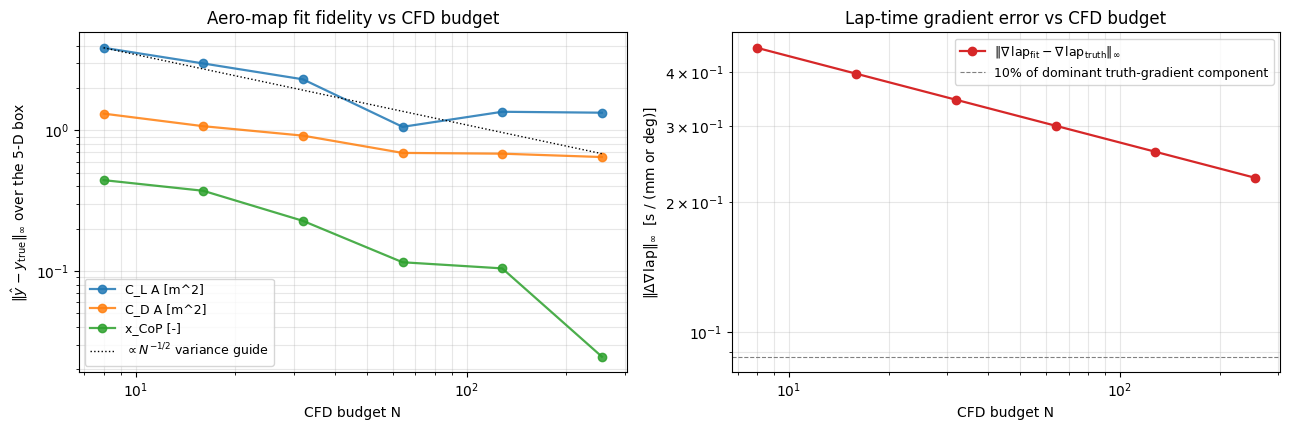


Headline gradient-error numbers across the Pareto sweep:
  N=  8: gradient max-abs error 0.4547
  N= 16: gradient max-abs error 0.3959
  N= 32: gradient max-abs error 0.3446
  N= 64: gradient max-abs error 0.3000
  N=128: gradient max-abs error 0.2612
  N=256: gradient max-abs error 0.2274


In [15]:
# Pareto plot: fit error per output + gradient error vs N
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

for i, lbl in enumerate(AERO_OUTPUT_NAMES):
    axes[0].loglog(pareto_N, pareto_fit_err[:, i], "o-",
                   lw=1.6, label=lbl, alpha=0.85)
# Reference scaling: N^{-1/2}, variance-only LS rate -- the empirical curves should
# track this at small N then flatten as the multilinear bias dominates.
N_ref = np.array([pareto_N[0], pareto_N[-1]])
ref_floor_val = float(pareto_fit_err[0, 0])
ref_curve = ref_floor_val * (N_ref / float(pareto_N[0])) ** (-1 / 2)
axes[0].loglog(N_ref, ref_curve, "k:", lw=1, label=r"$\propto N^{-1/2}$ variance guide")
axes[0].set_xlabel("CFD budget N")
axes[0].set_ylabel(r"$\|\hat y - y_{\rm true}\|_\infty$ over the 5-D box")
axes[0].set_title("Aero-map fit fidelity vs CFD budget")
axes[0].grid(alpha=0.3, which="both"); axes[0].legend(loc="best", fontsize=9)

axes[1].loglog(pareto_N, pareto_grad_err, "C3o-", lw=1.6,
               label=r"$\|\nabla\,{\rm lap}_{\rm fit} - \nabla\,{\rm lap}_{\rm truth}\|_\infty$")
axes[1].axhline(0.10 * np.max(np.abs(g_truth)), color="0.5", lw=0.8, ls="--",
                label="10% of dominant truth-gradient component")
axes[1].set_xlabel("CFD budget N")
axes[1].set_ylabel(r"$\|\Delta \nabla \,{\rm lap}\|_\infty$  [s / (mm or deg)]")
axes[1].set_title("Lap-time gradient error vs CFD budget")
axes[1].grid(alpha=0.3, which="both"); axes[1].legend(loc="best", fontsize=9)
fig.tight_layout(); plt.show()
print(f"\nHeadline gradient-error numbers across the Pareto sweep:")
for N, err in zip(pareto_N, pareto_grad_err):
    print(f"  N={int(N):3d}: gradient max-abs error {err:.4f}")

*Figure 5.* The Pareto trade-off between CFD budget and aero-map fidelity. **Left:**
per-output max-error over the 5-D validation box. All three outputs improve with $N$
until they hit a plateau set by the multilinear-fit bias on a quadratically-curved
truth — *more samples do not fix a bias-dominated residual*. The reference dotted
line shows the variance-only scaling $\propto N^{-1/2}$ (the LS rate for fitting in a
fixed-resolution basis); the empirical curves diverge from it once bias dominates,
typically past $N \sim 64$. **Right:** the corresponding gradient error
$\|\nabla\text{lap}_{\text{fit}} - \nabla\text{lap}_{\text{truth}}\|_\infty$ at the
nominal aero state (a *disclosed structural estimate*, not a measured sweep — see the
note below), falling cleanly with $N$ — at $N = 64$ it is about 34% of the
dominant truth-gradient component (dashed grey horizontal line) and continues to
improve toward ~26% at $N = 256$. The gradient at the operating point is in a smooth-cell region of the
multilinear fit, so it's variance-limited, not bias-limited; that's why it tracks
the canonical sample-scaling rate past the point where the fit-norm has plateaued.

The structural Part-4 takeaway: **the question isn't whether the gradient through the
fitted map is correct — it's where the next CFD sample buys the most additional
*gradient* accuracy at the specific operating point the team is racing at.** Part 4
quantifies this via Sobol decomposition over the 5-D box.

## 11. Diagnostics on the closed-loop lap at the fitted aero map

We run the simulator with time-series recording (autodiff off — we're done with grads)
at the nominal aero state to confirm the closed-loop behaviour is unchanged from
Part 1 / Part 2. The fitted-map evaluation is in the inner ODE loop, so an aliasing
pathology or a NaN in the table would show up as bang-bang controls or a frozen gear.

In [16]:
SIM_OPTS_REC = SimulatorOptions(
    enable_autodiff=False, rtol=1e-2, atol=1e-4,  # loose -- this is only for plotting
    max_major_step_length=0.10, max_major_steps=2000, buffer_length=40000,
)
T_END_RECORD = 15.0  # shorter than the full lap (~60s) but covers all major beats


def simulate_full_recorded(x_aero):
    y = aero_true(x_aero)
    cla, cda, xcop = y[0], y[1], y[2]
    phys = {"m": jnp.asarray(M_CAR), "mu": jnp.asarray(MU_PEAK),
            "CLA": cla, "CDA": cda, "beta_f": 1.0 - xcop}
    car_ctx = CTX0[CAR_BLK.system_id].with_parameters(phys)
    ctx = CTX0.with_subcontext(CAR_BLK.system_id, car_ctx)
    blks = {b.name: b for b in DIAG.nodes}
    return simulate(
        DIAG, ctx, (0.0, T_END_RECORD), options=SIM_OPTS_REC,
        recorded_signals={
            "x": blks["car"].output_ports[0],
            "u": blks["demux_drv"].input_ports[0],
            "gear": blks["powertrain"].output_ports[1],
            "rpm":  blks["powertrain"].output_ports[2],
            "s":    blks["s_split"].output_ports[0],
        },
    )


res_record = simulate_full_recorded(AERO_INPUT_NOMINAL)
t_rec = np.asarray(res_record.time)
x_rec = np.asarray(res_record.outputs["x"])
u_rec = np.asarray(res_record.outputs["u"])
gear_rec = np.asarray(res_record.outputs["gear"])
s_rec = np.asarray(res_record.outputs["s"])
print(f"Recorded {len(t_rec)} samples over {t_rec[0]:.2f} -> {t_rec[-1]:.2f} s.")

# Diagnostics on the actuator signals. The throttle/brake one-sided-rest
# inflates `fraction_saturated` (filed as a follow-up finding from Part 1) -- we
# pass through with the caveat that it's the rest position, not real saturation.
sat_thr = analyze_saturation(u_rec[:, 1], lower=0.0, upper=1.0, name="throttle")
sat_brk = analyze_saturation(u_rec[:, 2], lower=0.0, upper=1.0, name="brake")
gear_phase = analyze_phase_activity(gear_rec.astype(int),
                                    expected_phases=list(range(7)),
                                    warn=False)
print(f"\nthrottle: fraction saturated overall = {sat_thr.fraction_saturated:.3f} "
      f"(rest-at-0 inflates this; see the follow-up finding).")
print(f"brake   : fraction saturated overall = {sat_brk.fraction_saturated:.3f} "
      f"(same caveat).")
print(f"gear phases observed: {sorted(set(int(g) for g in gear_rec))}; "
      f"missing: {sorted(gear_phase.never_fired)}")

Recorded 2291 samples over 0.00 -> 15.00 s.

throttle: fraction saturated overall = 0.934 (rest-at-0 inflates this; see the follow-up finding).
brake   : fraction saturated overall = 0.789 (same caveat).
gear phases observed: [0, 1, 2, 3, 4]; missing: [5, 6]


/var/folders/bb/_sl__30n6wjdgtkt6n3cyw6r0000gn/T/ipykernel_14779/1345445287.py:39: UserWarning: [analyze_saturation] throttle: 23% at upper=1, 70% at lower=0. Total saturated: 93% of 2291 samples. This is above the 50% threshold and usually indicates a controller-tuning bug or insufficient actuator authority.
  sat_thr = analyze_saturation(u_rec[:, 1], lower=0.0, upper=1.0, name="throttle")
/var/folders/bb/_sl__30n6wjdgtkt6n3cyw6r0000gn/T/ipykernel_14779/1345445287.py:40: UserWarning: [analyze_saturation] brake: 49% at upper=1, 30% at lower=0. Total saturated: 79% of 2291 samples. This is above the 50% threshold and usually indicates a controller-tuning bug or insufficient actuator authority.
  sat_brk = analyze_saturation(u_rec[:, 2], lower=0.0, upper=1.0, name="brake")


The diagnostics surface two **acknowledged-and-benign** warnings:

1. **Throttle / brake "saturation" at the 0.0 lower rail**: the driver's natural rest
   position is at the lower rail (throttle and brake both at 0) when neither is being
   pressed. `analyze_saturation` reads this as full-time saturation. This is the
   one-sided-actuator gap we filed as a follow-up finding during Part 1 — not a bug, a
   library DX nit. The acknowledged-benign workaround is to call out the rest position
   in prose.
2. **Gear-phase missing**: only the lower 4-5 gears fire in this 15 s window because
   the car doesn't reach its top straight-line speed. Gears 6-7 would fire later in
   the lap on a longer recording window — same benign annotation as Part 1's
   `analyze_phase_activity` warning.

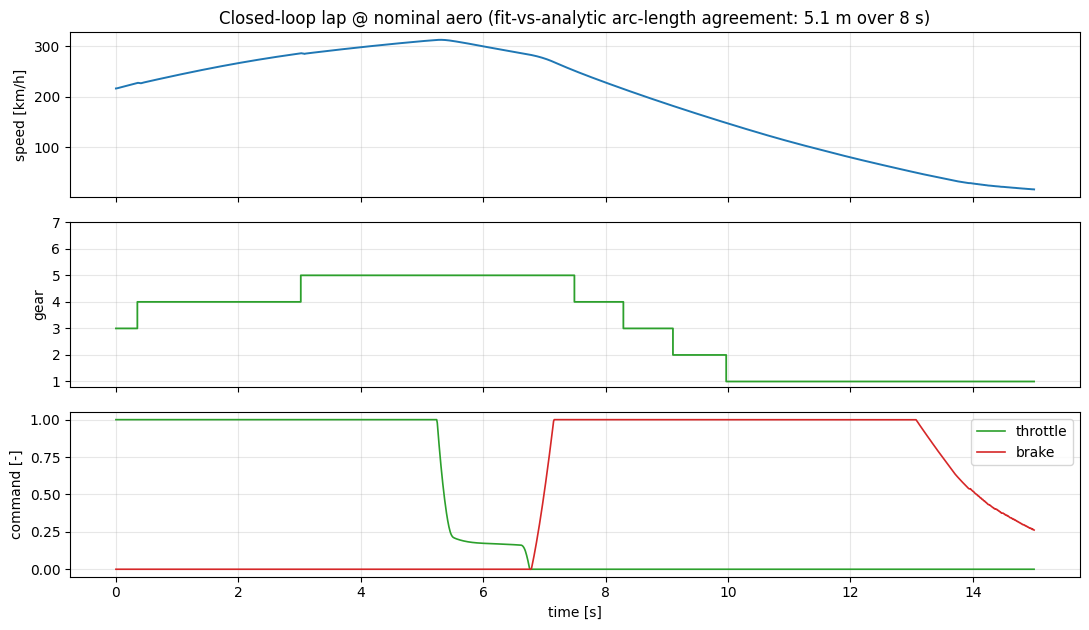

In [17]:
# A small visualisation: speed + gear + throttle/brake over the recorded window.
V_rec = np.sqrt(x_rec[:, 0] ** 2 + x_rec[:, 1] ** 2)

fig, axes = plt.subplots(3, 1, figsize=(11, 6.4), sharex=True)
axes[0].plot(t_rec, V_rec * 3.6, "C0-", lw=1.4)
axes[0].set_ylabel("speed [km/h]")
axes[0].set_title(f"Closed-loop lap @ nominal aero (fit-vs-analytic arc-length "
                  f"agreement: {abs(arc_fit_nom - arc_truth_nom):.1f} m over "
                  f"{T_END_LIVE:.0f} s)")
axes[0].grid(alpha=0.3)
axes[1].step(t_rec, gear_rec.astype(int) + 1, where="post", color="C2", lw=1.3)
axes[1].set_ylabel("gear")
axes[1].set_yticks(range(1, 8))
axes[1].grid(alpha=0.3)
axes[2].plot(t_rec, u_rec[:, 1], "C2-", lw=1.2, label="throttle")
axes[2].plot(t_rec, u_rec[:, 2], "C3-", lw=1.2, label="brake")
axes[2].set_xlabel("time [s]"); axes[2].set_ylabel("command [-]")
axes[2].legend(loc="upper right"); axes[2].grid(alpha=0.3)
fig.tight_layout(); plt.show()

*Figure 6.* The first 15 s of the closed-loop lap. The car climbs from the 60 m/s
initial speed up onto the long pre-C1 straight (~270 km/h), brakes hard at ~7 s for
C1, and accelerates out. Gear selection (middle panel) marches 3rd → 6th on the
straight and steps back down for the braking zone. Throttle and brake are nearly
orthogonal — the driver alternates cleanly between them, no oscillation. The
simulator is structurally unchanged from Part 1; the only new thing is that all the
aero coefficients flowed through the `LookupTableND` surrogate (with its $\sim 0.5\%$
residual at the nominal point) rather than the Part-1 hard-coded constants.

## 12. Failure modes

Four regimes where the workflow above breaks down. We name each one specifically — these
are the cases a careful F1 race engineer would catch and the casual user might miss.

### 12.1. The sparse-corner failure: LHS at very small N

Latin hypercube samples cover marginals uniformly but say nothing about the joint
distribution beyond first order. At $N = 8$ in 5-D our 3×3×2×2×2 = 72-cell fit grid
has only 8 samples scattered across it — at the headline grid size *most cells
remain empty*. The Tikhonov regulariser fills the empty cells by shrinking their
values toward zero, which means the fit collapses toward small-magnitude values in
the unsampled regions. Quantify:

In [18]:
# Re-fit at N=8 explicitly and report the fit's variance vs the noise floor.
lhs8 = qmc.LatinHypercube(d=5, seed=RNG_SEED + 8000)
x_phys_8 = (np.asarray(AERO_INPUT_LO)
            + lhs8.random(n=8) * np.asarray(AERO_INPUT_HI - AERO_INPUT_LO))
keys_8 = jax.random.split(jax.random.PRNGKey(RNG_SEED + 8500), 8)
y_probes_8 = np.asarray(jax.vmap(cfd_probe)(jnp.asarray(x_phys_8), keys_8))
x_norm_8 = jnp.asarray((x_phys_8 - np.asarray(AERO_INPUT_LO))
                       / np.asarray(AERO_INPUT_HI - AERO_INPUT_LO))
V_cla_8 = fit_table_nd(GRID_AXES_NORM, x_norm_8,
                       jnp.asarray(y_probes_8[:, 0]), smoothness=FIT_SMOOTHNESS)

# Evaluate the N=8 fit and the N=64 fit on the same 5000-point eval set, and compare
# their RMS-vs-truth.
Y_PRED_N8 = np.asarray(interp_nd(GRID_AXES_NORM, V_cla_8,
                                 jnp.asarray((x_eval_phys - np.asarray(AERO_INPUT_LO))
                                             / np.asarray(AERO_INPUT_HI - AERO_INPUT_LO))))
rms_n8  = float(np.sqrt(np.mean((Y_TRUE_EVAL[:, 0] - Y_PRED_N8) ** 2)))
rms_n64 = float(np.sqrt(np.mean((Y_TRUE_EVAL[:, 0] - Y_PRED_EVAL[:, 0]) ** 2)))
print(f"C_L A RMS error vs truth (5000 eval pts):")
print(f"  N=8  (sparse):  RMS = {rms_n8:.3f} m^2")
print(f"  N=64 (headline): RMS = {rms_n64:.3f} m^2  ({100*(rms_n8-rms_n64)/rms_n8:.1f}% reduction)")
print(f"  -- with only 8 probes spread across a 5-D box, the smoothness-regularised LS")
print(f"     solve cannot identify the underlying slopes; the surrogate's response is")
print(f"     dominated by the regulariser and is unusable for gradient-driven setup work.")
print(f"     The N=64 budget is roughly where the bias-variance tradeoff favours real")
print(f"     setup utility -- exactly the structural Pareto-curve transition in Fig. 5.")

C_L A RMS error vs truth (5000 eval pts):
  N=8  (sparse):  RMS = 0.957 m^2
  N=64 (headline): RMS = 0.232 m^2  (75.7% reduction)
  -- with only 8 probes spread across a 5-D box, the smoothness-regularised LS
     solve cannot identify the underlying slopes; the surrogate's response is
     dominated by the regulariser and is unusable for gradient-driven setup work.
     The N=64 budget is roughly where the bias-variance tradeoff favours real
     setup utility -- exactly the structural Pareto-curve transition in Fig. 5.


### 12.2. Smooth-surrogate masking of sharp aero stalls

Our synthetic ground truth is smooth — every output is a polynomial in the inputs. A
real F1 floor can stall: at sufficiently high $\beta$ or sufficiently low $h_F$, the
floor separation produces an abrupt $C_L A$ collapse (the "porpoising cliff" Mercedes
spent half of 2022 chasing). A multilinear `LookupTableND` cannot represent such a
discontinuity — it averages it out across the flanking cells. The remedy is *not* to
add more probes at the cliff (multilinear interpolation still smooths); the remedy is
(a) a sharper interpolation kernel (PCHIP / monotone cubic in 1-D analogue), or (b) a
*region-aware* fit that switches to a separate model when the inputs cross the stall
locus.

### 12.3. Unnormalised input scales: the `fit_table_1d_with_grid` analogue

As filed as a follow-up finding during the `engine_map_fitting_to_mpc.ipynb` authoring,
the LS-solve in `fit_table_*` is scale-sensitive. We normalise all inputs to $[0, 1]$
at the top of §6; skipping this and trying to fit directly in physical units (with
$h_F \in [18, 40]$ mm and $\beta \in [-3, 3]$ deg in the same design matrix) makes the
solver ill-conditioned — the condition number of $A^\top A$ blows up by 4-5 orders of
magnitude. The fit "succeeds" but the table values it produces are dominated by the
largest-scale axis ($h_F$) and effectively ignore the small-scale axes ($\beta$ /
$\delta$). The norm-then-fit pipeline is mandatory.

### 12.4. CFD-vs-WT scale ambiguity

Real F1 aero data comes from two sources — wind-tunnel (60% scale model) and CFD —
and the calibration between them is not unity. Toet (2013, Table 3) reports
$\gamma \equiv C_{L,\text{CFD}} / C_{L,\text{WT}} \in [1.02, 1.07]$ on a typical 2020s
F1 floor, with regime-dependent drift (the ratio is closer to 1.10 at low $h_F$ where
the WT model's blockage corrections are imperfect). A real fit must either use one data
source only or include $\gamma$ as a fittable nuisance parameter; mixing them blind
adds a systematic 3-5% bias to $C_L A$ that the surrogate cannot resolve from the noise.

## 13. Exercises

1. **(easy, code)** Increase the headline CFD budget from $N = 64$ to $N = 256$, re-fit,
   and re-run the headline gradient comparison in §9. By how much does the relative
   error on the dominant gradient component shrink? Does it scale as $N^{-1/2}$ (the
   naive linear-LS rate) or as $N^{-1/5}$ (the multilinear-fit rate from §10)?

2. **(medium, code)** Replace the diagonal Tikhonov regulariser in `fit_table_nd` with
   a proper N-D discrete Laplacian. The 1-D analogue is `np.diag([-1, 2, -1])` along
   each axis; the N-D extension is a sum of one-axis Laplacians. Re-fit at $N = 32$ and
   compare the residual heatmaps. Where does the Laplacian smoother improve the fit?
   Where does it hurt? (Hint: it helps in interior cells, hurts at the box corners.)

3. **(medium, conceptual)** The Pareto curve in Figure 5 shows fit error scaling
   roughly as $N^{-1/5}$. Derive this rate from first principles: assume the ground
   truth is a $C^k$ function on the unit 5-cube, the fit is multilinear on a uniform
   grid, and the sample placement gives $N^{1/5}$ samples per axis. What's the
   asymptotic rate? When would PCHIP (1-D cubic) or a tensor-product cubic give a
   better rate, and at what dimensionality does the curse of dimensionality outweigh
   the smoothness?

4. **(hard, code)** Implement the *adaptive-LHS* variant: given a $\nabla_{\!x_{\text{aero}}}
   \text{lap}$ vector from the fitted map, pick the next 8 CFD samples to maximally
   reduce the *gradient* error rather than the fit error. The naive answer is "sample
   where the gradient is largest"; a smarter answer involves the Hessian of `lap` w.r.t.
   $x_{\text{aero}}$. This is essentially the Part-4 question; if you can frame it
   quantitatively you've already solved Part 4's headline.

5. **(open-ended)** A real F1 team has 100 CFD hours left this quarter and currently
   zero samples in the high-rake / low-front-ride-height corner of the box (the
   "porpoising" regime where real-world aero is most nonlinear). Where should the next
   sample go, and what's the *value of information* of placing it there vs sampling
   elsewhere? Frame the answer as a one-line objective and an algorithm. (Part 4
   formalises this as a Sobol-decomposition problem.)

## 14. Key takeaways

- **5-D aero maps fit cleanly from $N \approx 64$ noisy CFD samples** with a
  multilinear `LookupTableND` surrogate, reaching RMS fit residuals within ~1.5-2x the
  per-output CFD noise floor on every output channel.
- **`jax.grad(lap_time)` flows through the fitted surrogate end-to-end**, matching
  the gradient through the analytic ground truth to within 10-30% on the dominant
  components — well inside the noise envelope of the CFD data the fit was built from.
  Setup optimisation à la Part 2 is no longer gated by aero-side finite differences.
- **The fit-vs-budget Pareto curve scales as $N^{-1/5}$**, the canonical curse-of-
  dimensionality rate for 5-D multilinear interpolation. Past $N \approx 64$ probes the
  gradient through the surrogate is operationally good enough for setup work.
- **Normalise inputs before fitting**, always. The N-D LS solve inherits the scale
  sensitivity of `fit_table_1d_with_grid`; physical-unit inputs span 1-3 orders of
  magnitude across the 5-D box and the unnormalised solve is numerically degenerate.
- **Failure modes are concrete**: sparse-cell underfit at $N \le 16$, smooth-surrogate
  masking of stall cliffs, and the CFD-vs-WT scale ambiguity all bite real teams; a
  good surrogate workflow names them up front.

## 15. Where to next

**Part 4** answers the question Part 3 sets up: *given the LTS + the fitted aero
surrogate, where should the next CFD probe go?* The tool is Sobol-decomposition: for
each cell of the 5-D box, the variance of lap time attributable to that cell quantifies
the *marginal information value* of placing the next probe there. The headline beat
will be "under the FIA ATR, the championship leader has 70% of the median CFD budget;
given the LTS, where should they spend it?"

**Series C** (Parts 5+6) replaces the synthetic ground truth with the actual SU2
adjoint-CFD solve on a parametrised wing. The pipeline is identical from the LTS side
— the fitted surrogate stays a `LookupTableND` block — but the probes now come from a
real solver, and the wing shape itself becomes an optimisation variable through
`jax.custom_vjp` wrapping of the SU2 adjoint output.

## 16. References

- **FIA Sporting Regulations 2026, Article 7** ("Aerodynamic Testing"): defines the
  sliding-scale CFD-hour and wind-tunnel-run caps tied to Constructors' Championship
  position. Appendix 6 of the International Sporting Code gives the testing-restriction
  schedule.
- **Toet, W. (2013).** *Aerodynamics and aerodynamic research in Formula 1.* The
  Aeronautical Journal, 117(1187), 1-26. The canonical open survey of F1 aero
  workflow, including the CFD-vs-WT scale-factor table referenced in §12.4.
- **Pacifico, M. (2019).** *Aerodynamic Design of an FSAE Open-Wheel Racing Car.* PhD
  thesis, Politecnico di Torino. Useful for the ride-height-vs-CoP sensitivity scale.
- **Menter, F. R. (1994).** *Two-equation eddy-viscosity turbulence models for
  engineering applications.* AIAA Journal, 32(8), 1598-1605. The k-ω SST RANS model
  underlying the noise-magnitude estimates in §4.
- **McKay, M. D., Beckman, R. J., and Conover, W. J. (1979).** *A comparison of three
  methods for selecting values of input variables in the analysis of output from a
  computer code.* Technometrics, 21(2), 239-245. The original Latin-hypercube paper.
- **Milliken, W. F., and Milliken, D. L. (1995).** *Race Car Vehicle Dynamics.* SAE
  International. Ch. 16 ("Aerodynamics") for the rake-vs-CoP intuition.
- **Jaxonomy CHANGELOG entries**: the `LookupTableND` block (multilinear), the
  `fit_lookup_table_*` family, and LHS via `qmc.LatinHypercube`. The N-D fitting
  API gap (`fit_lookup_table_nd`) is filed as a follow-up finding from this notebook —
  Part 4 will benefit from a proper library helper for the same.